# 1. Import Libraries, Configuration Setup, and Load the Dataset

## 1.1 Install \& Import Libraries

In [ ]:
# !pip install peft==0.13.2, transformers==4.41.1

In [ ]:
# !pip install wordcloud

In [ ]:
# !pip install imblearn

In [ ]:
# !pip install lightgbm

In [ ]:
## Python Standard Library
import json
import os
import re
import string
import random
import time
import warnings
from itertools import cycle, product, combinations
from collections import Counter

## Stat tools
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests

## Data Science & Plotting (Pandas, Numpy, etc.)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from tqdm import tqdm

## Scikit-learn (sklearn)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_curve,
    auc,
    accuracy_score,
    ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils import resample, shuffle
from sklearn.utils.class_weight import compute_class_weight

## Other Machine Learning Libraries
from imblearn.over_sampling import SMOTE, RandomOverSampler
from lightgbm import LGBMClassifier
from scipy.sparse import hstack
import joblib

## NLTK (Natural Language Toolkit)
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, SnowballStemmer, WordNetLemmatizer

## PyTorch
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

# Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Transformers (Hugging Face)
from transformers import (
    AlbertTokenizer,
    AlbertForSequenceClassification,
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)

## Setup & Configuration
# Set up Matplotlib for notebooks
%matplotlib inline

# Suppress warnings
warnings.filterwarnings("ignore")

# Download NLTK data
nltk.download("stopwords")
nltk.download("wordnet")

# Set device for PyTorch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## 1.2 Configuration

In [ ]:
# --- 1. Project & Path Settings ---
# Root path in your Google Drive
DRIVE_PROJECT_PATH = "/content/drive/MyDrive/NLP_Projects/HateSpeech/4o_mini_on_human_majority"

# Raw data csv file
RAW_DATA_FILE = "hatexplain_model_ready_with_ai_labels.csv"

# Filenames for your trained models
ALBERT_MODEL_FILE = "best_albert_model.pth"
GRU_MODEL_FILE = "best_GRU_model.pth"
GRU_PARAMS_FILE = "best_gru_params.json"
CNN_MODEL_FILE = "best_cnn_model.pth"
CNN_PARAMS_FILE = "best_cnn_params.json"

# --- 2. Dataset & Label Settings ---
# The column names from your source DataFrame
TEXT_COLUMN = "text"
LABEL_COLUMN = "ai_label_mini"
LABEL_COLUMN_ENCODED = "ai_label_Encoded" # For our new numeric labels

# --- 3. Training & Tokenizer Settings ---
VOCAB_SIZE = 10000
MAX_TOKEN_LENGTH = 200
BATCH_SIZE = 32  # (Increased from 4 for much better GPU efficiency)
N_ITERATIONS = 10 # Number of iterations for tuning
RANDOM_STATE = 42 # For reproducibility

# --- 4. Full Paths (Auto-generated) ---
# This creates the full paths, so you don"t have to join them later
RAW_DATA_PATH = os.path.join(DRIVE_PROJECT_PATH, RAW_DATA_FILE)
BEST_GRU_PATH = os.path.join(DRIVE_PROJECT_PATH, GRU_MODEL_FILE)
BEST_GRU_PARAMS_PATH = os.path.join(DRIVE_PROJECT_PATH, GRU_PARAMS_FILE)
BEST_CNN_PATH = os.path.join(DRIVE_PROJECT_PATH, CNN_MODEL_FILE)
BEST_CNN_PARAMS_PATH = os.path.join(DRIVE_PROJECT_PATH, CNN_PARAMS_FILE)
BEST_ALBERT_PATH = os.path.join(DRIVE_PROJECT_PATH, ALBERT_MODEL_FILE)

print("--- Configuration Loaded ---")
print(f"Project Path: {DRIVE_PROJECT_PATH}")
print(f"ALBERT Model Path: {BEST_ALBERT_PATH}")
print(f"GRU Model Path: {BEST_GRU_PATH}")

--- Configuration Loaded ---
Project Path: /content/drive/MyDrive/NLP_Projects/HateSpeech/4o_mini_on_human_majority
ALBERT Model Path: /content/drive/MyDrive/NLP_Projects/HateSpeech/4o_mini_on_human_majority/best_albert_model.pth
GRU Model Path: /content/drive/MyDrive/NLP_Projects/HateSpeech/4o_mini_on_human_majority/best_GRU_model.pth


## 1.3 Load the data

In [ ]:
from google.colab import drive
drive.mount("/content/drive/")

Mounted at /content/drive/


In [ ]:
# Load the raw data from our config path into a generic DataFrame
df_raw0 = pd.read_csv(RAW_DATA_PATH, index_col = 0)
print(f"Loaded raw data with {df_raw0.shape[0]} rows.")

df_raw0.head()

Loaded raw data with 20148 rows.


,text,label_id1,label_id2,label_id3,human_majority,is_pure,human_pure,ai_label_mini,ai_label_text_mini,ai_p_normal_mini,ai_p_offensive_mini,ai_p_hate_mini
id,,,,,,,,,,,,
1179055004553900032_twitter,i dont think im getting my baby them white 9 h...,normal,normal,normal,normal,True,normal,NORMAL,normal,0.90,0.1,0.00
1179063826874032128_twitter,we cannot continue calling ourselves feminists...,normal,normal,normal,normal,True,normal,NORMAL,normal,0.85,0.1,0.05
1178793830532956161_twitter,nawt yall niggers ignoring me,normal,normal,hatespeech,normal,False,NaN,HATE,hatespeech,0.00,0.1,0.90
1179088797964763136_twitter,<user> i am bit confused coz chinese ppl can n...,hatespeech,offensive,hatespeech,hatespeech,False,NaN,HATE,hatespeech,0.00,0.2,0.80
1179085312976445440_twitter,this bitch in whataburger eating a burger with...,hatespeech,hatespeech,offensive,hatespeech,False,NaN,HATE,hatespeech,0.00,0.1,0.90


In [ ]:
df_raw = df_raw0[df_raw0["human_majority"].notna()].copy()
print(f"Loaded raw data with {df_raw.shape[0]} rows.")

Loaded raw data with 19229 rows.


# 2. Data Exploration \& Master Data Preparation

## 2.1 Data Preparation

In [ ]:
df_raw.shape

(19229, 12)

In [ ]:
df_raw.columns

Index(['text', 'label_id1', 'label_id2', 'label_id3', 'human_majority',
       'is_pure', 'human_pure', 'ai_label_mini', 'ai_label_text_mini',
       'ai_p_normal_mini', 'ai_p_offensive_mini', 'ai_p_hate_mini'],
      dtype='object')

In [ ]:
df_raw = df_raw.reset_index()
df_raw = df_raw[[TEXT_COLUMN, LABEL_COLUMN]]
print(df_raw)

                                                    text ai_label_mini
0      i dont think im getting my baby them white 9 h...        NORMAL
1      we cannot continue calling ourselves feminists...        NORMAL
2                          nawt yall niggers ignoring me          HATE
3      <user> i am bit confused coz chinese ppl can n...          HATE
4      this bitch in whataburger eating a burger with...          HATE
...                                                  ...           ...
19224  if ur still on twitter tell carlton i said his...     OFFENSIVE
19225  when i first got on here and said i hate trump...          HATE
19226  was macht der moslem wenn der zion gegen seine...          HATE
19227  it is awful look at world demographics asians ...          HATE
19228  the jewish globalist elite have only imported ...          HATE

[19229 rows x 2 columns]


In [ ]:
classes = df_raw[LABEL_COLUMN].unique()
NUM_CLASSES = len(classes)

print(f"The unique classes are: {classes}")
print(f"Number of unique classes: {NUM_CLASSES}")
print("\nDatapoints per class:")
print(df_raw[LABEL_COLUMN].value_counts())

The unique classes are: ['NORMAL' 'HATE' 'OFFENSIVE']
Number of unique classes: 3

Datapoints per class:
ai_label_mini
HATE         9910
OFFENSIVE    6297
NORMAL       3022
Name: count, dtype: int64


In [ ]:
random.seed(2025)
df_raw = shuffle(df_raw)
df_raw

,text,ai_label_mini
1358,aa the direct appeal to the most base human de...,HATE
8225,it officially october where my niggers jason n...,HATE
14,all of my exes were cute but they were hoes i ...,NORMAL
287,fanbloodytastic by time these leeches are held...,HATE
10978,some dear friends refugee from raqqa just sent...,NORMAL
...,...,...
7632,it sounds like a kike to me i doubt that is ev...,HATE
18164,arablies so it is ok for arabs to colonise but...,HATE
6507,<number> with regard to the disastrous initiat...,HATE
15613,it been nearly three weeks since a man describ...,NORMAL


## 2.2 Master Data Preparation

In [ ]:
# --- Text Cleaning Function ---
def clean_text_master(text):
    if pd.isna(text):
        return ""

    text = text.lower()
    text = re.sub(r"http\S+", "<URL>", text)
    text = re.sub(r"@\w+", "<USER>", text)
    text = re.sub(r"#\w+", "<HASHTAG>", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

print("Cleaning text...")
# Create a new, clean DataFrame
df_clean = df_raw.copy()
df_clean[TEXT_COLUMN] = df_clean[TEXT_COLUMN].apply(clean_text_master)

# --- Label Encoding ---
print("Encoding labels...")
label_encoder = LabelEncoder()

# Fit and transform the labels, adding them to our clean DataFrame
df_clean[LABEL_COLUMN_ENCODED] = label_encoder.fit_transform(df_clean[LABEL_COLUMN])

# --- 4. Final Check ---
print(f"Master 'df_clean' created with {df_clean.shape[0]} rows.")
print(f"Label mapping: {list(label_encoder.classes_)}")
print(f"Config NUM_CLASSES = {NUM_CLASSES}")
print("\nData head:")
print(df_clean.head())

Cleaning text...
Encoding labels...
Master 'df_clean' created with 19229 rows.
Label mapping: ['HATE', 'NORMAL', 'OFFENSIVE']
Config NUM_CLASSES = 3

Data head:
                                                    text ai_label_mini  \
1358   aa the direct appeal to the most base human de...          HATE   
8225   it officially october where my niggers jason n...          HATE   
14     all of my exes were cute but they were hoes i ...        NORMAL   
287    fanbloodytastic by time these leeches are held...          HATE   
10978  some dear friends refugee from raqqa just sent...        NORMAL   

       ai_label_Encoded  
1358                  0  
8225                  0  
14                    1  
287                   0  
10978                 1  


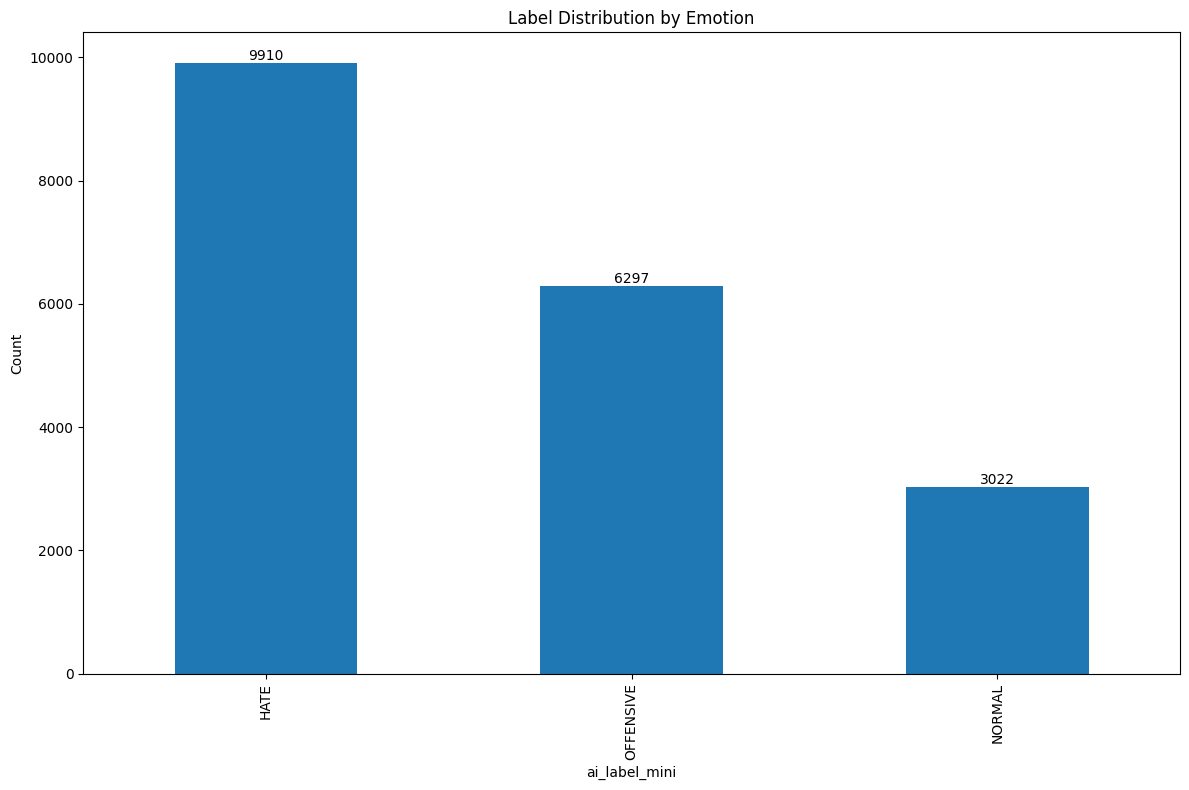

In [ ]:
# As shown by below plot, there are class-imbalance issues
# Therefore, we would need to balance the class distribution in the training set, we will do so by using a balanced class weights in training
plt.figure(figsize = (12,8))
status_counts = df_clean[LABEL_COLUMN].value_counts()
ax = status_counts.plot(kind = "bar")
for i, v in enumerate(status_counts):
    ax.text(i, v, str(v), ha = "center", va = "bottom")

plt.title("Label Distribution by Emotion")
plt.xlabel(LABEL_COLUMN)
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 2.3 Master Data Split

### 2.3.1 Define groups for splitting

In [ ]:
groups = df_clean[TEXT_COLUMN]
y = df_clean[LABEL_COLUMN_ENCODED]

### 2.3.2. First split: train vs test

In [ ]:
gss_test = GroupShuffleSplit(
    n_splits = 1,
    test_size = 0.20,        # 20% test
    random_state = RANDOM_STATE,
)

train_idx, test_idx = next(gss_test.split(df_clean, y, groups = groups))

# Use a separate split array (positional) to avoid .loc / index confusion
split = np.array(["train"] * len(df_clean), dtype = object)
split[test_idx] = "test"
df_clean["split"] = split

print("After train/test split:")
print(df_clean["split"].value_counts())

After train/test split:
split
train    15375
test      3854
Name: count, dtype: int64


### 2.3.3. Second split: train -> train + val (within train only)

In [ ]:
train_mask = df_clean["split"] == "train"
train_pos_indices = np.where(train_mask)[0]      # positions in the full df
df_train_only = df_clean.loc[train_mask].copy().reset_index(drop = True)

groups_train = df_train_only[TEXT_COLUMN]
y_train = df_train_only[LABEL_COLUMN_ENCODED]

gss_val = GroupShuffleSplit(
    n_splits = 1,
    test_size = 0.25,        # 25% of *train* -> 0.25 * 0.8 = 0.20 of full data
    random_state = RANDOM_STATE,
)

train_idx2, val_idx = next(
    gss_val.split(df_train_only, y_train, groups = groups_train)
)

# Map positions within df_train_only back to global positions in df
train2_global = train_pos_indices[train_idx2]
val_global = train_pos_indices[val_idx]

# Update split array
split[:] = "train"
split[val_global] = "val"
split[test_idx] = "test"
df_clean["split"] = split

print("\nFinal split counts:")
print(df_clean["split"].value_counts())



Final split counts:
split
train    11531
test      3854
val       3844
Name: count, dtype: int64


### 2.3.4. Sanity checks

In [ ]:
# (a) No text group appears in more than one split
group_split_counts = df_clean.groupby(TEXT_COLUMN)["split"].nunique()
n_leaky_groups = (group_split_counts > 1).sum()
print("\nNumber of text groups that appear in >1 split:", n_leaky_groups)
assert n_leaky_groups == 0, "Some text groups leak across splits!"

# (b) Rough proportions
n_total = len(df_clean)
split_props = df_clean["split"].value_counts(normalize = True)
print("\nSplit proportions (approx):")
print(split_props)



Number of text groups that appear in >1 split: 0

Split proportions (approx):
split
train    0.599667
test     0.200426
val      0.199906
Name: proportion, dtype: float64


### 2.3.5. Save master split

In [ ]:
split_path = os.path.join(DRIVE_PROJECT_PATH, "hatexplain_master_split.csv")
df_clean.to_csv(split_path, index = False)
print("\nSaved master split to:", split_path)


Saved master split to: /content/drive/MyDrive/NLP_Projects/HateSpeech/4o_mini_on_human_majority/hatexplain_master_split.csv


# 3. Classical ML Modeling

## 3.0 Pre-processing for classical ML Models


### Step 1: Copy clean data for classical ML models

In [ ]:
df_ml = df_clean.copy()

### Step 2: ML-specific preprocessing on ALL rows (train/val/test)

In [ ]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def ml_preprocess(text: str) -> str:
    if not isinstance(text, str):
        return ""
    # remove stopwords
    tokens = [w for w in text.split() if w not in stop_words]
    # lemmatize
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return " ".join(tokens)

# Use a separate column for ML text so original df_clean['text'] is untouched
df_ml["text_ml"] = df_ml[TEXT_COLUMN].apply(ml_preprocess)

print("Example original vs ML-preprocessed text:")
print(df_ml[[TEXT_COLUMN, "text_ml"]].head())

Example original vs ML-preprocessed text:
                                                    text  \
1358   aa the direct appeal to the most base human de...   
8225   it officially october where my niggers jason n...   
14     all of my exes were cute but they were hoes i ...   
287    fanbloodytastic by time these leeches are held...   
10978  some dear friends refugee from raqqa just sent...   

                                                 text_ml  
1358   aa direct appeal base human desire cheap kike ...  
8225            officially october nigger jason n freddy  
14           ex cute hoe guess attract fly looking thots  
287    fanbloodytastic time leech held account especi...  
10978  dear friend refugee raqqa sent phileena home s...  


### Step 3: Build train/val/test splits for ML

In [ ]:
# Use the master split directly:
df_train_ml = df_ml[df_ml["split"] == "train"].copy()
df_val_ml = df_ml[df_ml["split"] == "val"].copy()
df_test_ml = df_ml[df_ml["split"] == "test"].copy()

print("ML split sizes:", len(df_train_ml), len(df_val_ml), len(df_test_ml))


# Texts and labels for ML (use cleaned master text)
X_train_ml = df_train_ml["text_ml"].tolist()
X_val_ml = df_val_ml["text_ml"].tolist()
X_test_ml = df_test_ml["text_ml"].tolist()

# Labels: pick whichever label column you’re modeling in this panel
y_train_ml = df_train_ml[LABEL_COLUMN].astype(str).values
y_val_ml = df_val_ml[LABEL_COLUMN].astype(str).values
y_test_ml = df_test_ml[LABEL_COLUMN].astype(str).values

ML split sizes: 11531 3844 3854


### Step 4: TF-IDF Vectorization

In [ ]:
tfidf = TfidfVectorizer(
    max_features = 10000,
    stop_words = "english"   # you can drop this, since you've already removed stopwords
)

# Fit on TRAIN ONLY
X_train_ml_tfidf = tfidf.fit_transform(X_train_ml)

# Transform val & test
X_val_ml_tfidf = tfidf.transform(X_val_ml)
X_test_ml_tfidf = tfidf.transform(X_test_ml)

print("TF-IDF shapes:",
      X_train_ml_tfidf.shape,
      X_val_ml_tfidf.shape,
      X_test_ml_tfidf.shape)

TF-IDF shapes: (11531, 10000) (3844, 10000) (3854, 10000)


### Step 5: Define Model Evaluation Functions for Classical Machine Learning Models


In [ ]:
# --- Helper Function 1: F1 Score Bootstrapping ---
def bootstrap_f1_ci(y_true, y_pred, n_iterations = 1000, average = "weighted"):
    """Calculates the F1 score and 95% CI using bootstrapping."""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    f1_scores = []

    for _ in range(n_iterations):
        indices = resample(np.arange(len(y_true)))
        try:
            f1 = f1_score(y_true[indices], y_pred[indices], average = average)
            f1_scores.append(f1)
        except ValueError:
            continue  # Skip bootstrap sample if it's invalid

    if not f1_scores:
        return np.nan, np.nan, np.nan

    f1_mean = np.mean(f1_scores)
    ci_lower = np.percentile(f1_scores, 2.5)
    ci_upper = np.percentile(f1_scores, 97.5)
    return f1_mean, ci_lower, ci_upper


# --- Helper Function 2: Macro-AUC Bootstrapping ---
def bootstrap_auc_ci_multiclass(y_true, y_scores, n_iterations = 1000, average = "macro"):
    """Calculates the Macro-AUC and 95% CI using bootstrapping."""
    auc_scores = []
    y_true = np.array(y_true)
    y_scores = np.array(y_scores)

    for _ in range(n_iterations):
        indices = resample(np.arange(len(y_true)))

        y_true_sample = y_true[indices]
        y_scores_sample = y_scores[indices]

        try:
            auc_sample = roc_auc_score(
                y_true_sample,
                y_scores_sample,
                average = average,
                multi_class = "ovr"
            )
            auc_scores.append(auc_sample)
        except ValueError:
            continue  # Skip bootstrap sample if it's missing a class

    if not auc_scores:
        return np.nan, np.nan, np.nan

    return (
        np.mean(auc_scores),
        np.percentile(auc_scores, 2.5),
        np.percentile(auc_scores, 97.5),
    )


# --- Helper Function 3: Confusion Matrix Plot ---
def plot_confusion_matrix(
    y_true,
    y_pred,
    labels,
    model_name = "Model",
    save_dir = None,
    cmap_name = "Blues",
):
    """
    Plots a labeled confusion matrix and optionally saves it to disk.
    """
    conf_matrix = confusion_matrix(y_true, y_pred, labels = labels)

    plt.figure(figsize = (8, 6))
    sns.heatmap(
        conf_matrix,
        annot = True,
        fmt = "d",
        cmap = cmap_name,
        xticklabels = labels,
        yticklabels = labels,
        vmin = 0,
        vmax = conf_matrix.max(),
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok = True)
        cm_path = os.path.join(save_dir, f"{model_name}_confusion_matrix.png")
        plt.savefig(cm_path, dpi = 300)
        print(f"Saved confusion matrix to: {cm_path}")

    plt.show()


# --- Helper Function 4: Multi-class ROC Plot ---
def plot_multiclass_roc(
    y_true,
    y_score,
    classes_list,
    label_prefix = "Model",
    save_dir = None,
):
    """
    Plots a multi-class ROC curve (one-vs-rest) and optionally saves it.
    """
    y_true_bin = label_binarize(y_true, classes = classes_list)
    n_classes = len(classes_list)

    fpr = {}
    tpr = {}
    roc_auc = {}

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    colors = sns.color_palette("mako", n_classes)

    plt.figure(figsize = (10, 8))
    for i, (class_label, color) in enumerate(zip(classes_list, colors)):
        plt.plot(
            fpr[i],
            tpr[i],
            color = color,
            lw = 2,
            label = f"Class {class_label} (AUC = {roc_auc[i]:.2f})",
        )

    plt.plot([0, 1], [0, 1], "k--", lw = 2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{label_prefix} - Multi-class ROC Curve")
    plt.legend(loc = "lower right")
    plt.tight_layout()

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok = True)
        roc_path = os.path.join(save_dir, f"{label_prefix}_roc_curve.png")
        plt.savefig(roc_path, dpi = 300)
        print(f"Saved ROC curve to: {roc_path}")

    plt.show()


# --- MAIN EVALUATION WRAPPER (for scikit-learn models) ---
def evaluate_ML_multiclass(model, X_test, y_test, model_name = "Model"):
    """
    Runs a full evaluation for a fitted scikit-learn classifier.
    Calculates metrics, CIs, and plots, and saves CM/ROC to DRIVE_PROJECT_PATH.
    """
    print(f"\n--- Evaluation Report: {model_name} ---\n")

    y_pred = model.predict(X_test)
    classes_list = model.classes_

    print("Classification Report:")
    print(classification_report(y_test, y_pred, digits = 4, labels = classes_list))

    f1_mean, f1_ci_low, f1_ci_high = bootstrap_f1_ci(
        y_test, y_pred, average = "weighted"
    )
    print(f"Weighted F1 Score: {f1_mean:.4f}")
    print(f"95% CI for F1 Score: [{f1_ci_low:.4f}, {f1_ci_high:.4f}]")

    plot_confusion_matrix(
        y_test,
        y_pred,
        labels = classes_list,
        model_name = model_name,
        save_dir = DRIVE_PROJECT_PATH,
        cmap_name = "Blues",
    )

    if hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_test)
    elif hasattr(model, "decision_function"):
        y_scores = model.decision_function(X_test)
    else:
        print("Model doesn't support probability or decision scores.")
        return

    auc_score, auc_ci_low, auc_ci_high = bootstrap_auc_ci_multiclass(
        y_test, y_scores
    )
    print(f"\nMacro-Averaged AUC: {auc_score:.4f}")
    print(f"95% CI for Macro-Averaged AUC: [{auc_ci_low:.4f}, {auc_ci_high:.4f}]")

    plot_multiclass_roc(
        y_test,
        y_scores,
        classes_list,
        label_prefix = model_name,
        save_dir = DRIVE_PROJECT_PATH,
    )

## 3.1 Logistic Regression

### Step 1: Hyperparameter Tuning

In [ ]:
random.seed(2025)

# Parameter grid for logistic regression
param_grid = {
    "C": [0.1, 1, 10],                # Regularization strength
    "solver": ["lbfgs", "saga"],      # Optimization solvers
    "penalty": ["l2"],                # L2 regularization
    "multi_class": ["multinomial"],   # Multiclass strategy
    "class_weight": ["balanced", None],     # Handle class imbalance
}

# Initialize variables to track the best model and parameters
best_f1 = 0
best_model_lr = None
best_params_lr = None

# Start timer
start_time = time.time()
print("Starting manual Logistic Regression tuning...")

# Iterate through reduced parameter grid
for C, solver, penalty, multi_class, class_weight in product(
        param_grid["C"], param_grid["solver"], param_grid["penalty"], param_grid["multi_class"], param_grid["class_weight"]):
    try:
        # Set n_jobs for 'saga' solver (lbfgs doesn't support it)
        n_jobs = -1 if solver == "saga" else None

        # Create the Logistic Regression model
        model = LogisticRegression(
            C = C,
            solver = solver,
            penalty = penalty,
            multi_class = multi_class,
            class_weight = class_weight,
            max_iter = 1000,
            random_state = RANDOM_STATE,
            n_jobs = n_jobs
        )

        # Train the model
        model.fit(X_train_ml_tfidf, y_train_ml)

        # Validate the model on validation set
        y_val_pred = model.predict(X_val_ml_tfidf)
        f1 = f1_score(y_val_ml, y_val_pred, average = "weighted")

        # Update the best model if current one is better
        if f1 > best_f1:
            best_f1 = f1
            best_model_lr = model
            best_params_lr = {
                "C": C,
                "solver": solver,
                "penalty": penalty,
                "multi_class": multi_class,
                "class_weight": class_weight
            }
            print(f"New Best F1: {f1:.4f} with params: {best_params_lr}")

    except Exception as e:
        print(f"Skipping combination due to error: {e}")

# End timer
end_time = time.time()
total_time = end_time - start_time
print(f"Total Parameter Tuning Time: {total_time:.2f} seconds")

# Print the best parameters and F1 score on validation set
print("\nBest Hyperparameters:", best_params_lr)
print("Best Validation F1-Score:", best_f1)

Starting manual Logistic Regression tuning...
New Best F1: 0.6838 with params: {'C': 0.1, 'solver': 'lbfgs', 'penalty': 'l2', 'multi_class': 'multinomial', 'class_weight': 'balanced'}
New Best F1: 0.7052 with params: {'C': 1, 'solver': 'lbfgs', 'penalty': 'l2', 'multi_class': 'multinomial', 'class_weight': 'balanced'}
Total Parameter Tuning Time: 59.94 seconds

Best Hyperparameters: {'C': 1, 'solver': 'lbfgs', 'penalty': 'l2', 'multi_class': 'multinomial', 'class_weight': 'balanced'}
Best Validation F1-Score: 0.7051732115474575


### Step 2: Model Construction

In [ ]:
# Create the SVM model with the best params
LR = LogisticRegression(
    **best_params_lr,
    max_iter = 1000,
    random_state = RANDOM_STATE
)

# Train the model
LR.fit(X_train_ml_tfidf, y_train_ml)

LogisticRegression(C=1, class_weight='balanced', max_iter=1000,
                   multi_class='multinomial', random_state=42)

### Step 3: Model Evaluation


--- Evaluation Report: Logistic Regression ---

Classification Report:
              precision    recall  f1-score   support

        HATE     0.8587    0.7585    0.8055      1979
      NORMAL     0.4123    0.6064    0.4908       597
   OFFENSIVE     0.6384    0.6135    0.6257      1278

    accuracy                         0.6868      3854
   macro avg     0.6365    0.6594    0.6407      3854
weighted avg     0.7165    0.6868    0.6971      3854

Weighted F1 Score: 0.6971
95% CI for F1 Score: [0.6838, 0.7110]
Saved confusion matrix to: /content/drive/MyDrive/NLP_Projects/HateSpeech/4o_mini_on_human_majority/Logistic Regression_confusion_matrix.png


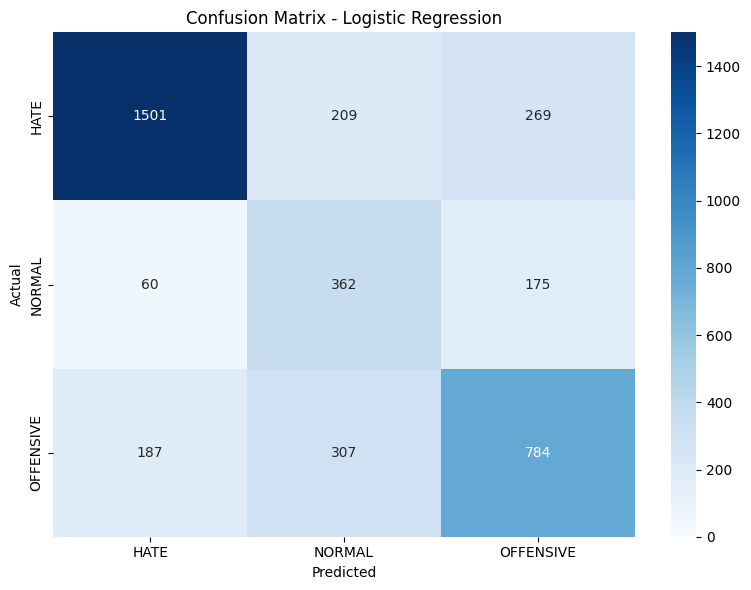


Macro-Averaged AUC: 0.8522
95% CI for Macro-Averaged AUC: [0.8421, 0.8618]
Saved ROC curve to: /content/drive/MyDrive/NLP_Projects/HateSpeech/4o_mini_on_human_majority/Logistic Regression_roc_curve.png


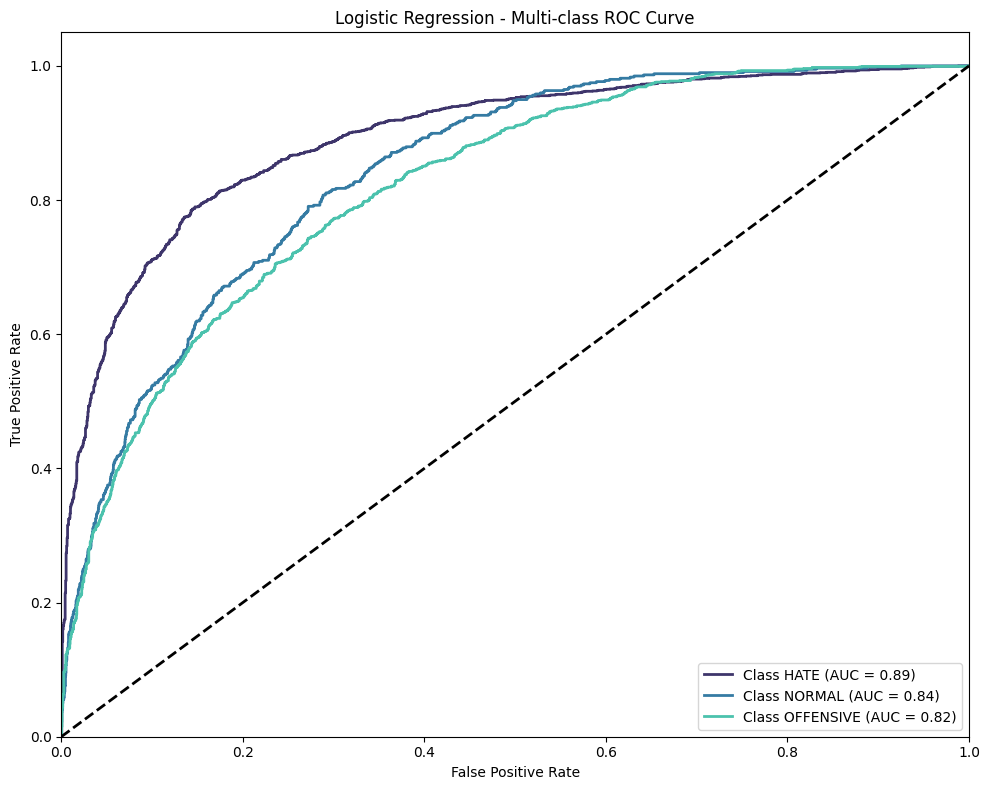

In [ ]:
evaluate_ML_multiclass(LR, X_test_ml_tfidf, y_test_ml, model_name = "Logistic Regression")


### Step 4: Model Interpretation

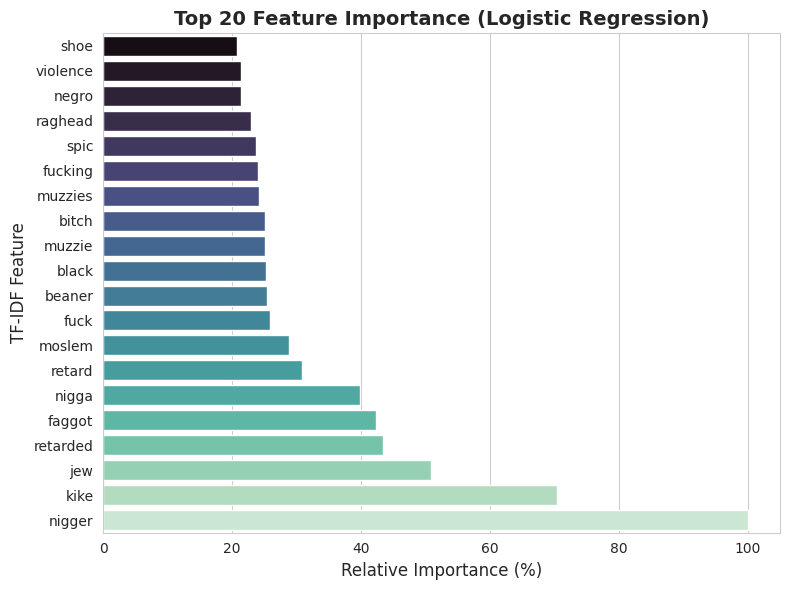

       Feature  Importance  Scaled Importance
6571    nigger    7.156076         100.000000
5009      kike    5.036911          70.386489
4656       jew    3.634342          50.786803
7813  retarded    3.111713          43.483515
2690    faggot    3.028559          42.321511
6567     nigga    2.846623          39.779102
7811    retard    2.208846          30.866722
6347    moslem    2.058952          28.772076
3017      fuck    1.853426          25.900036
647     beaner    1.814539          25.356624
777      black    1.803731          25.205585
6433    muzzie    1.799295          25.143602
763      bitch    1.793940          25.068760
6434   muzzies    1.729520          24.168554
3022   fucking    1.722009          24.063591
8614      spic    1.692312          23.648607
7536   raghead    1.646778          23.012298
6507     negro    1.527357          21.343500
9620  violence    1.526940          21.337675
8301      shoe    1.481908          20.708383


In [ ]:
# --- 1. Check if Model is Fitted ---
if LR is not None and hasattr(LR, "coef_"):

    # --- 2. Get Feature Names and Coefficients ---

    # Get the feature names (the words) from your fitted TF-IDF vectorizer
    feature_names = tfidf.get_feature_names_out()

    # --- CRITICAL IMPROVEMENT ---
    # Your model is 'multinomial', so LR.coef_ has shape (n_classes, n_features).
    # We must average the importance across all classes, not just take the first one.
    if LR.coef_.shape[0] > 1:
        # Average the *absolute* coefficient values across all 8 classes
        importances = np.abs(LR.coef_).mean(axis = 0)
    else:
        # Fallback for a binary/OVR model (takes absolute value of the one row)
        importances = np.abs(LR.coef_[0])

    # --- 3. Create and Process Importance DataFrame ---

    # Create a DataFrame to hold features and their calculated importances
    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    })

    # Normalize importance (rescale to 0–100)
    # This makes the chart easier to read as "Relative Importance (%)"
    importance_df["Scaled Importance"] = (
        importance_df["Importance"] / importance_df["Importance"].max()
    ) * 100

    # Sort by importance and get the top 20 features
    top_20_features = importance_df.sort_values(by = "Importance", ascending = False).head(20)

    # --- 4. Plot the Top 20 Features ---

    # Plot (horizontal bar chart)
    plt.figure(figsize = (8, 6))
    sns.set_style("whitegrid")
    sns.barplot(
        x = "Scaled Importance",
        y = "Feature",
        data = top_20_features[::-1],  # Reverse [::-1] to plot the most important feature at the top
        palette = "mako"
    )

    # Set titles and labels
    plt.title("Top 20 Feature Importance (Logistic Regression)", fontsize = 14, fontweight = "bold")
    plt.xlabel("Relative Importance (%)", fontsize = 12)
    plt.ylabel("TF-IDF Feature", fontsize = 12)
    plt.xticks(fontsize = 10)
    plt.yticks(fontsize = 10)
    plt.tight_layout()

    # Save a high-resolution version of the plot for your paper
    lr_imp_fig_path = os.path.join(DRIVE_PROJECT_PATH, "lr_token_importance_top20.png")
    plt.savefig(lr_imp_fig_path, dpi = 300)
    plt.show()

    # --- 5. Print the Top 20 (Optional) ---
    print(top_20_features[["Feature", "Importance", "Scaled Importance"]])

else:
    print("No LR model was trained successfully. Unable to display feature importance.")

## 3.2 Support Vector Machine

### Step 1: Hyperparameter Tuning

In [ ]:
random.seed(2025)

# Parameter grid
param_grid = {
    "C": [0.1, 1, 10],            # Regularization strength
    "kernel": ["linear", "rbf"],  # Commonly used kernels
    "class_weight": ["balanced", None], # Handle class imbalance
    "gamma": ["scale"],           # Default kernel coefficient, other options are available if needed
}

# Initialize variables to track the best model and parameters
best_f1 = 0
best_model_svc = None
best_params_svc = None

# Start timer
start_time = time.time()
print("Starting manual SVC tuning...")

# Iterate through reduced parameter grid
for C, kernel, class_weight, gamma in product(
        param_grid["C"], param_grid["kernel"], param_grid["class_weight"], param_grid["gamma"]):
    try:
        # Create the SVM model
        model = SVC(
            C = C,
            kernel = kernel,
            class_weight = class_weight,
            gamma = gamma,
            random_state = RANDOM_STATE,
            probability = True  # <-- CRITICAL: Required for AUC calculation
        )

        # Train the model
        model.fit(X_train_ml_tfidf, y_train_ml)

        # Validate the model on validation set
        y_val_pred = model.predict(X_val_ml_tfidf)
        f1 = f1_score(y_val_ml, y_val_pred, average = "weighted")

        # Update the best model if current one is better
        if f1 > best_f1:
            best_f1 = f1
            best_model_svc = model
            best_params_svc = {
                "C": C,
                "kernel": kernel,
                "class_weight": class_weight,
                "gamma": gamma
            }
            print(f"New Best F1: {f1:.4f} with params: {best_params_svc}")

    except Exception as e:
        print(f"Skipping combination due to error: {e}")

# End timer
end_time = time.time()
total_time = end_time - start_time
print(f"Total Parameter Tuning Time: {total_time:.2f} seconds")

# Print the best parameters and F1 score on validation set
print("\nBest Hyperparameters:", best_params_svc)
print("Best Validation F1-Score:", best_f1)

Starting manual SVC tuning...
New Best F1: 0.6486 with params: {'C': 0.1, 'kernel': 'linear', 'class_weight': 'balanced', 'gamma': 'scale'}
New Best F1: 0.6981 with params: {'C': 1, 'kernel': 'linear', 'class_weight': 'balanced', 'gamma': 'scale'}
New Best F1: 0.7029 with params: {'C': 1, 'kernel': 'linear', 'class_weight': None, 'gamma': 'scale'}
New Best F1: 0.7106 with params: {'C': 1, 'kernel': 'rbf', 'class_weight': 'balanced', 'gamma': 'scale'}
Total Parameter Tuning Time: 1216.37 seconds

Best Hyperparameters: {'C': 1, 'kernel': 'rbf', 'class_weight': 'balanced', 'gamma': 'scale'}
Best Validation F1-Score: 0.710620581635565


### Step 2: Model Construction

In [ ]:
# Create the SVM model with the best params
SVM = SVC(
    **best_params_svc,
    random_state = RANDOM_STATE,
    probability = True
)

# Train the model
SVM.fit(X_train_ml_tfidf, y_train_ml)

SVC(C=1, class_weight='balanced', probability=True, random_state=42)

### Step 3: Model Evaluation


--- Evaluation Report: SVM ---

Classification Report:
              precision    recall  f1-score   support

        HATE     0.8337    0.8029    0.8180      1979
      NORMAL     0.5121    0.4975    0.5047       597
   OFFENSIVE     0.6389    0.6839    0.6606      1278

    accuracy                         0.7161      3854
   macro avg     0.6615    0.6614    0.6611      3854
weighted avg     0.7193    0.7161    0.7173      3854

Weighted F1 Score: 0.7177
95% CI for F1 Score: [0.7034, 0.7322]
Saved confusion matrix to: /content/drive/MyDrive/NLP_Projects/HateSpeech/4o_mini_on_human_majority/SVM_confusion_matrix.png


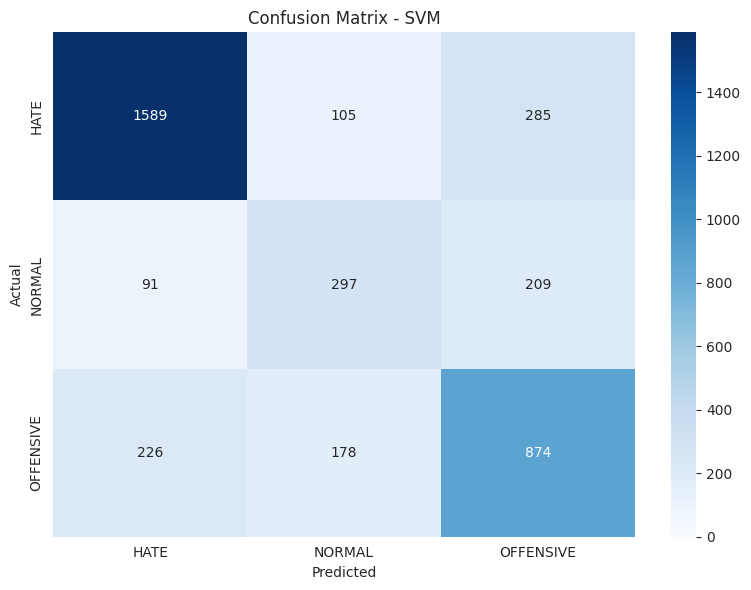


Macro-Averaged AUC: 0.8600
95% CI for Macro-Averaged AUC: [0.8505, 0.8694]
Saved ROC curve to: /content/drive/MyDrive/NLP_Projects/HateSpeech/4o_mini_on_human_majority/SVM_roc_curve.png


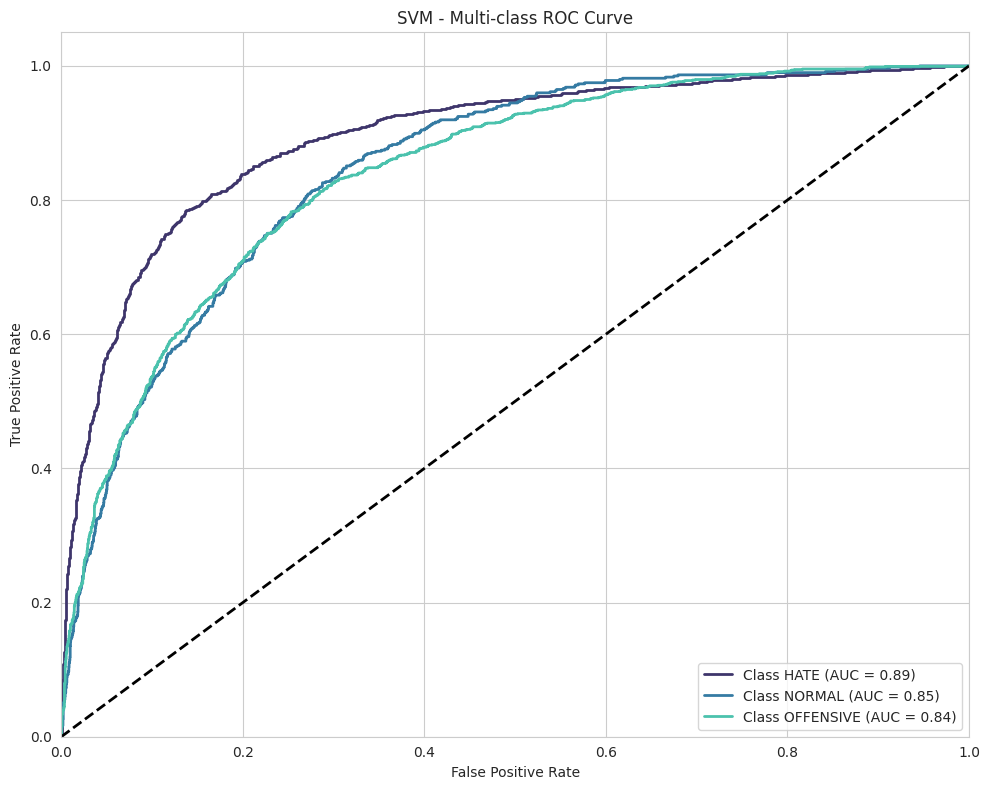

In [ ]:
evaluate_ML_multiclass(SVM, X_test_ml_tfidf, y_test_ml, model_name = "SVM")

### Step 4: Model Interpretation

Starting Permutation Importance calculation for SVM...
Using a subsample of the validation set for efficiency.
Permutation importance on 1000 samples, 10000 features.
Permutation importance finished in 9785.15 seconds.


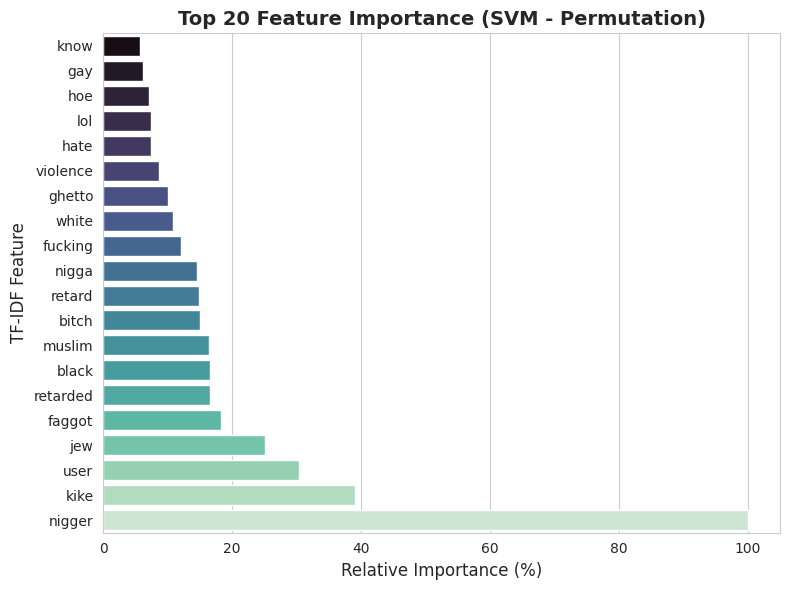

       Feature  Importance (Mean)  Scaled Importance
6571    nigger           0.075721         100.000000
5009      kike           0.029642          39.146758
9524      user           0.022954          30.313953
4656       jew           0.019053          25.162496
2690    faggot           0.013892          18.345719
7813  retarded           0.012584          16.618988
777      black           0.012506          16.515486
6410    muslim           0.012394          16.368138
763      bitch           0.011417          15.077842
7811    retard           0.011298          14.920599
6567     nigga           0.011035          14.573859
3022   fucking           0.009163          12.100487
9782     white           0.008181          10.804548
3146    ghetto           0.007618          10.061217
9620  violence           0.006564           8.669111
3431      hate           0.005674           7.493170
5653       lol           0.005600           7.395935
3550       hoe           0.005422           7.

In [ ]:
# --- 1. Check if Model is Fitted ---
if SVM is not None and hasattr(SVM, "decision_function"):

    print("Starting Permutation Importance calculation for SVM...")
    print("Using a subsample of the validation set for efficiency.")

    # --- 2. Subsample validation set for permutation importance ---
    max_samples = 1000  # you can change the max_samples if needed
    n_val = X_val_ml_tfidf.shape[0]

    if n_val > max_samples:
        rng = np.random.RandomState(RANDOM_STATE)
        idx = rng.choice(n_val, size = max_samples, replace = False)
        X_perm_sparse = X_val_ml_tfidf[idx]
        y_perm = y_val_ml[idx]
    else:
        X_perm_sparse = X_val_ml_tfidf
        y_perm = y_val_ml

    # Convert to dense for permutation_importance
    X_perm = X_perm_sparse.toarray()

    print(f"Permutation importance on {X_perm.shape[0]} samples, "
          f"{X_perm.shape[1]} features.")

    # --- 3. Run Permutation Importance ---
    start_time = time.time()

    result = permutation_importance(
        SVM,
        X_perm,
        y_perm,
        n_repeats = 5,        # fewer repeats for speed
        random_state = RANDOM_STATE,
        n_jobs = -1,          # use all CPU cores
        scoring = "f1_weighted"
    )

    end_time = time.time()
    print(f"Permutation importance finished in {end_time - start_time:.2f} seconds.")

    # --- 4. Process the results ---
    feature_names = tfidf.get_feature_names_out()

    importance_df_svm = pd.DataFrame({
        "Feature": feature_names,
        "Importance (Mean)": result.importances_mean,
        "Importance (Std)": result.importances_std
    })

    # Clip small negatives to zero for readability
    importance_df_svm["Importance (Mean)"] = (
        importance_df_svm["Importance (Mean)"].clip(lower = 0)
    )

    # Scale to [0, 100] for relative importance
    max_mean = importance_df_svm["Importance (Mean)"].max()
    if max_mean > 0:
        importance_df_svm["Scaled Importance"] = (
            importance_df_svm["Importance (Mean)"] / max_mean * 100
        )
    else:
        importance_df_svm["Scaled Importance"] = 0.0

    # Top 20 features
    top_20_features_svm = (
        importance_df_svm
        .sort_values(by = "Importance (Mean)", ascending = False)
        .head(20)
    )

    # --- 5. Plot in grayscale ---
    plt.figure(figsize = (8, 6))
    sns.set_style("whitegrid")

    # Reverse order so most important is at top
    df_plot = top_20_features_svm.iloc[::-1]

    sns.barplot(
        x = "Scaled Importance",
        y = "Feature",
        data = df_plot,
        palette = "mako"
    )

    plt.title("Top 20 Feature Importance (SVM - Permutation)", fontsize = 14, fontweight = "bold")
    plt.xlabel("Relative Importance (%)", fontsize = 12)
    plt.ylabel("TF-IDF Feature", fontsize = 12)
    plt.xticks(fontsize = 10)
    plt.yticks(fontsize = 10)
    plt.tight_layout()

    svm_imp_fig_path = os.path.join(DRIVE_PROJECT_PATH, "svm_token_importance_top20.png")
    plt.savefig(svm_imp_fig_path, dpi = 300)
    plt.show()

    print(top_20_features_svm[["Feature", "Importance (Mean)", "Scaled Importance"]])

else:
    print("No SVM model was trained successfully, or model lacks decision_function. "
          "Unable to compute permutation-based feature importance.")

## 3.3 Random Forest

### Step 1: Hyperparameter Tuning

In [ ]:
random.seed(2025)

# Parameter grid for Random Forest
param_grid = {
    "n_estimators": [50, 100, 200],       # Number of trees
    "max_depth": [None, 10, 20],          # Depth of the tree
    "min_samples_split": [2, 5, 10],      # Minimum samples required to split a node
    "min_samples_leaf": [1, 2, 4],        # Minimum samples required at a leaf node
    "class_weight": ["balanced", None],   # Handle class imbalance
}

# Initialize variables to track the best model and parameters
best_f1 = 0
best_model_rf = None
best_params_rf = None

# Start timer
start_time = time.time()
print("Starting manual Random Forest tuning...")

# Iterate through reduced parameter grid
for n_estimators, max_depth, min_samples_split, min_samples_leaf, class_weight in product(
        param_grid["n_estimators"],
        param_grid["max_depth"],
        param_grid["min_samples_split"],
        param_grid["min_samples_leaf"],
        param_grid["class_weight"]):
    try:
        # Create the Random Forest model with current parameters
        model = RandomForestClassifier(
            n_estimators = n_estimators,
            max_depth = max_depth,
            min_samples_split = min_samples_split,
            min_samples_leaf = min_samples_leaf,
            class_weight = class_weight,
            random_state = RANDOM_STATE,
            n_jobs = -1  # <-- Add n_jobs = -1 to speed up individual model training
        )

        # Train the model on the training set
        model.fit(X_train_ml_tfidf, y_train_ml)

        # Validate the model on the (single) validation set
        y_val_pred = model.predict(X_val_ml_tfidf)
        f1 = f1_score(y_val_ml, y_val_pred, average = "weighted")

        # Update the best model if current one is better
        if f1 > best_f1:
            best_f1 = f1
            best_model_rf = model
            best_params_rf = {
                "n_estimators": n_estimators,
                "max_depth": max_depth,
                "min_samples_split": min_samples_split,
                "min_samples_leaf": min_samples_leaf,
                "class_weight": class_weight
            }
            print(f"New Best F1: {f1:.4f} with params: {best_params_rf}")

    except Exception as e:
        print(f"Skipping combination due to error: {e}")

# End timer
end_time = time.time()
total_time = end_time - start_time
print(f"Total Parameter Tuning Time: {total_time:.2f} seconds")

# Print the best parameters and F1 score on validation set
print("\nBest Hyperparameters:", best_params_rf)
print("Best Validation F1-Score:", best_f1)

Starting manual Random Forest tuning...
New Best F1: 0.7051 with params: {'n_estimators': 50, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'class_weight': 'balanced'}
New Best F1: 0.7060 with params: {'n_estimators': 50, 'max_depth': None, 'min_samples_split': 5, 'min_samples_leaf': 1, 'class_weight': 'balanced'}
New Best F1: 0.7073 with params: {'n_estimators': 50, 'max_depth': None, 'min_samples_split': 10, 'min_samples_leaf': 1, 'class_weight': 'balanced'}
New Best F1: 0.7083 with params: {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'class_weight': 'balanced'}
New Best F1: 0.7095 with params: {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 5, 'min_samples_leaf': 1, 'class_weight': 'balanced'}
New Best F1: 0.7124 with params: {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 10, 'min_samples_leaf': 1, 'class_weight': 'balanced'}
Total Parameter Tuning Time: 132.58 seconds

Best Hyperparameters: 

### Step 2: Model Construction

In [ ]:
# Create the Random Forest model with the best params
RandomForest = RandomForestClassifier(
    **best_params_rf,
    random_state = RANDOM_STATE
)

# Train the model
RandomForest.fit(X_train_ml_tfidf, y_train_ml)

RandomForestClassifier(class_weight='balanced', min_samples_split=10,
                       random_state=42)

### Step 3: Model Evaluation


--- Evaluation Report: RandomForest ---

Classification Report:
              precision    recall  f1-score   support

        HATE     0.8271    0.8221    0.8246      1979
      NORMAL     0.4811    0.4908    0.4859       597
   OFFENSIVE     0.6495    0.6495    0.6495      1278

    accuracy                         0.7135      3854
   macro avg     0.6526    0.6541    0.6533      3854
weighted avg     0.7146    0.7135    0.7141      3854

Weighted F1 Score: 0.7139
95% CI for F1 Score: [0.7002, 0.7273]
Saved confusion matrix to: /content/drive/MyDrive/NLP_Projects/HateSpeech/4o_mini_on_human_majority/RandomForest_confusion_matrix.png


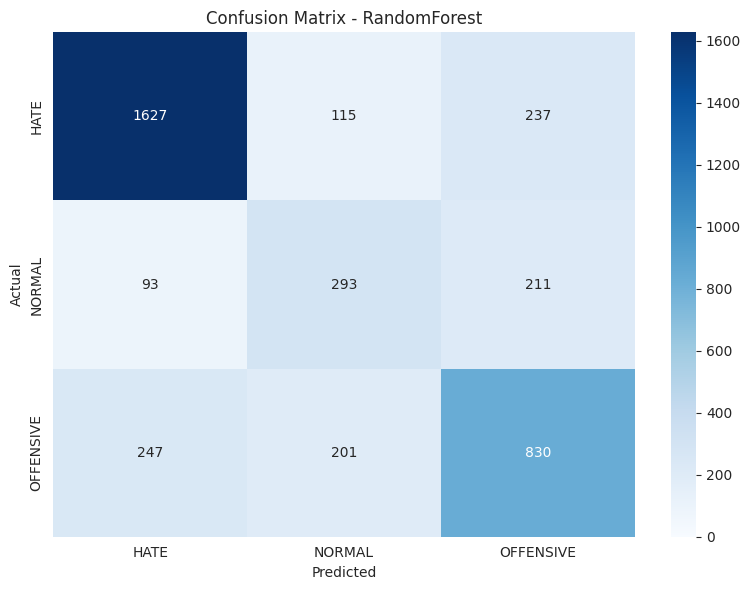


Macro-Averaged AUC: 0.8570
95% CI for Macro-Averaged AUC: [0.8479, 0.8668]
Saved ROC curve to: /content/drive/MyDrive/NLP_Projects/HateSpeech/4o_mini_on_human_majority/RandomForest_roc_curve.png


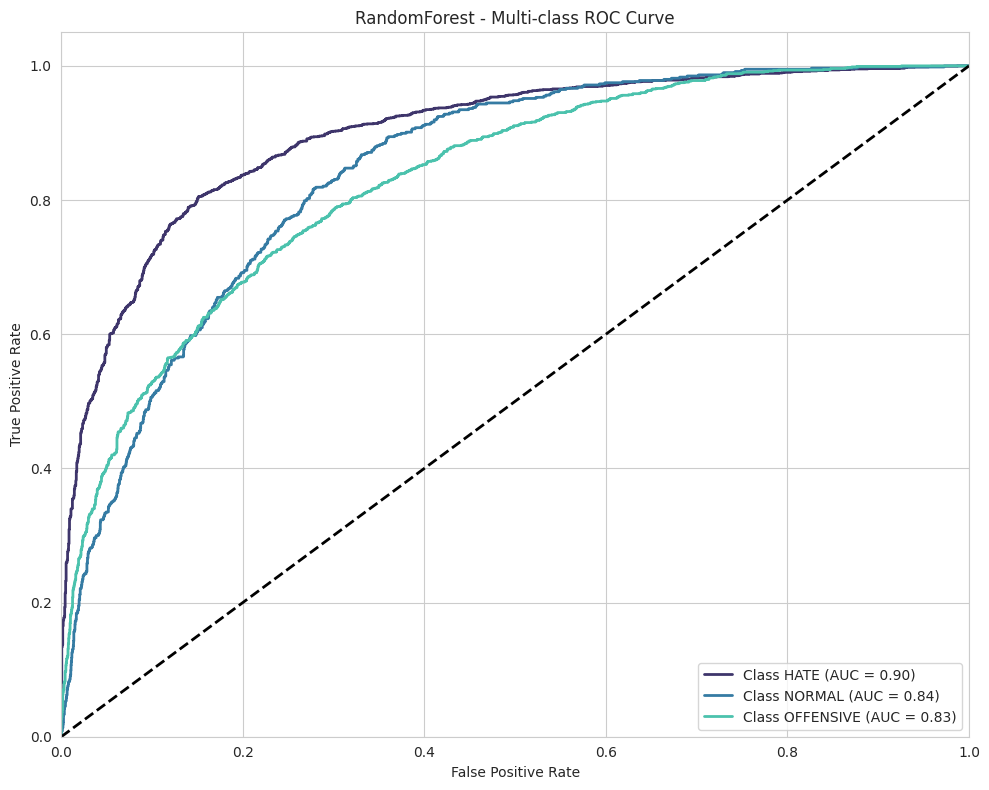

In [ ]:
evaluate_ML_multiclass(RandomForest, X_test_ml_tfidf, y_test_ml, model_name = "RandomForest")


### Step 4: Model Interpretation

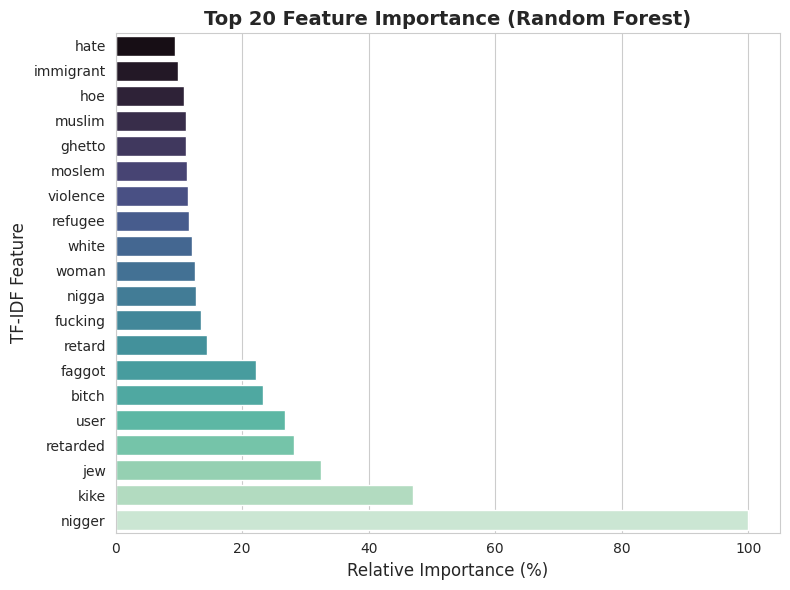

        Feature  Importance  Scaled Importance
6571     nigger    0.057066         100.000000
5009       kike    0.026829          47.013349
4656        jew    0.018489          32.399728
7813   retarded    0.016087          28.190669
9524       user    0.015265          26.750723
763       bitch    0.013260          23.236047
2690     faggot    0.012691          22.239128
7811     retard    0.008220          14.404718
3022    fucking    0.007735          13.555338
6567      nigga    0.007301          12.794353
9853      woman    0.007195          12.608719
9782      white    0.006939          12.160337
7658    refugee    0.006665          11.679503
9620   violence    0.006511          11.410481
6347     moslem    0.006484          11.361632
3146     ghetto    0.006386          11.189744
6410     muslim    0.006321          11.076737
3550        hoe    0.006193          10.851736
3967  immigrant    0.005648           9.897521
3431       hate    0.005383           9.432447


In [ ]:
# --- 1. Check if Model is Fitted ---
if RandomForest is not None:

    # --- 2. Get Feature Names and Importances ---

    # Get the feature names (the words) from your fitted TF-IDF vectorizer
    feature_names = tfidf.get_feature_names_out()

    # Get the feature importances from the trained Random Forest model
    # (This is the mean decrease in impurity, or Gini importance)
    feature_importance = RandomForest.feature_importances_

    # --- 3. Create and Process Importance DataFrame ---

    # Create a DataFrame to hold features and their scores
    importance_df_rf = pd.DataFrame({
        "Feature": feature_names,
        "Importance": feature_importance
    })

    # Normalize importance (rescale to 0–100)
    importance_df_rf["Scaled Importance"] = (
        importance_df_rf["Importance"] / importance_df_rf["Importance"].max()
    ) * 100

    # Sort by importance and get the top 20 features
    top_20_features_rf = importance_df_rf.sort_values(by = "Importance", ascending = False).head(20)

    # --- 4. Plot the Top 20 Features ---

    plt.figure(figsize = (8, 6))
    sns.set_style("whitegrid")
    sns.barplot(
        x = "Scaled Importance",
        y = "Feature",
        data = top_20_features_rf[::-1],  # Reverse [::-1] to plot the most important feature at the top
        palette = "mako"
    )

    # Set titles and labels
    plt.title("Top 20 Feature Importance (Random Forest)", fontsize = 14, fontweight = "bold")
    plt.xlabel("Relative Importance (%)", fontsize = 12)
    plt.ylabel("TF-IDF Feature", fontsize = 12)
    plt.xticks(fontsize = 10)
    plt.yticks(fontsize = 10)
    plt.tight_layout()

    # Save a high-resolution version of the plot for your paper
    rf_imp_fig_path = os.path.join(DRIVE_PROJECT_PATH, "rf_token_importance_top20.png")
    plt.savefig(rf_imp_fig_path, dpi = 300)
    plt.show()

    # Optionally print the top 20
    print(top_20_features_rf[["Feature", "Importance", "Scaled Importance"]])

else:
    print("No model was trained successfully. Unable to display feature importance.")

## 3.4 LGBM

### Step 1: Hyperparameter Tuning

In [ ]:
import time
from itertools import product
from lightgbm import LGBMClassifier
from sklearn.metrics import f1_score

random.seed(1234)

# Parameter grid for LightGBM
param_grid = {
    "n_estimators": [100, 200],          # Number of boosting iterations
    "learning_rate": [0.01, 0.1, 0.2],       # Learning rate
    "num_leaves": [31, 63],              # Maximum number of leaves in a tree
    "max_depth": [None, 10],             # Maximum tree depth
    "class_weight": ["balanced", None],      # Handle class imbalance
}

# Initialize variables to track the best model and parameters
best_f1 = 0
best_model_lgbm = None
best_params_lgbm = None

# Start timer
start_time = time.time()
print("Starting manual LightGBM tuning...")

# Iterate through reduced parameter grid
for n_estimators, learning_rate, num_leaves, max_depth, class_weight in product(
        param_grid["n_estimators"],
        param_grid["learning_rate"],
        param_grid["num_leaves"],
        param_grid["max_depth"],
        param_grid["class_weight"]):
    try:
        # Create the LightGBM model with current parameters
        model = LGBMClassifier(
            objective = "multiclass",
            n_estimators = n_estimators,
            learning_rate = learning_rate,
            num_leaves = num_leaves,
            max_depth = max_depth,
            class_weight = class_weight,
            random_state = RANDOM_STATE,
            n_jobs = -1  # <-- Use all CPU cores
        )

        # Train the model
        model.fit(X_train_ml_tfidf, y_train_ml)

        # Validate the model on validation set
        y_val_pred = model.predict(X_val_ml_tfidf)
        f1 = f1_score(y_val_ml, y_val_pred, average = "weighted")

        # Update the best model if current one is better
        if f1 > best_f1:
            best_f1 = f1
            best_model_lgbm = model
            best_params_lgbm = {
                "n_estimators": n_estimators,
                "learning_rate": learning_rate,
                "num_leaves": num_leaves,
                "max_depth": max_depth,
                "class_weight": class_weight
            }
            print(f"New Best F1: {f1:.4f} with params: {best_params_lgbm}")

    except Exception as e:
        print(f"Skipping combination due to error: {e}")

# End timer
end_time = time.time()
total_time = end_time - start_time
print(f"Total Parameter Tuning Time: {total_time:.2f} seconds")

# Print the best parameters and F1 score on validation set
print("\nBest Hyperparameters:", best_params_lgbm)
print("Best Validation F1-Score:", best_f1)

Streaming output truncated to the last 5000 lines.
[LightGBM] [Info] Total Bins 26140
[LightGBM] [Info] Number of data points in the train set: 11531, number of used features: 1053
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

### Step 2: Model Construction

In [ ]:
# Create the LightGBM model with the best params
LGBM = LGBMClassifier(
    objective = "multiclass",
    **best_params_lgbm,
    random_state = RANDOM_STATE,
    importance_type = "gain",
    n_jobs = -1 # <-- Good to add this for speed
)

# Train the model
LGBM.fit(X_train_ml_tfidf, y_train_ml)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.019211 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 26140
[LightGBM] [Info] Number of data points in the train set: 11531, number of used features: 1053
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


LGBMClassifier(class_weight='balanced', importance_type='gain',
               learning_rate=0.2, max_depth=None, n_jobs=-1,
               objective='multiclass', random_state=42)

### Step 3: Model Evaluation


--- Evaluation Report: LightGBM ---

Classification Report:
              precision    recall  f1-score   support

        HATE     0.8567    0.7585    0.8046      1979
      NORMAL     0.4047    0.6080    0.4859       597
   OFFENSIVE     0.6398    0.6033    0.6210      1278

    accuracy                         0.6837      3854
   macro avg     0.6338    0.6566    0.6372      3854
weighted avg     0.7148    0.6837    0.6944      3854

Weighted F1 Score: 0.6944
95% CI for F1 Score: [0.6808, 0.7083]
Saved confusion matrix to: /content/drive/MyDrive/NLP_Projects/HateSpeech/4o_mini_on_human_majority/LightGBM_confusion_matrix.png


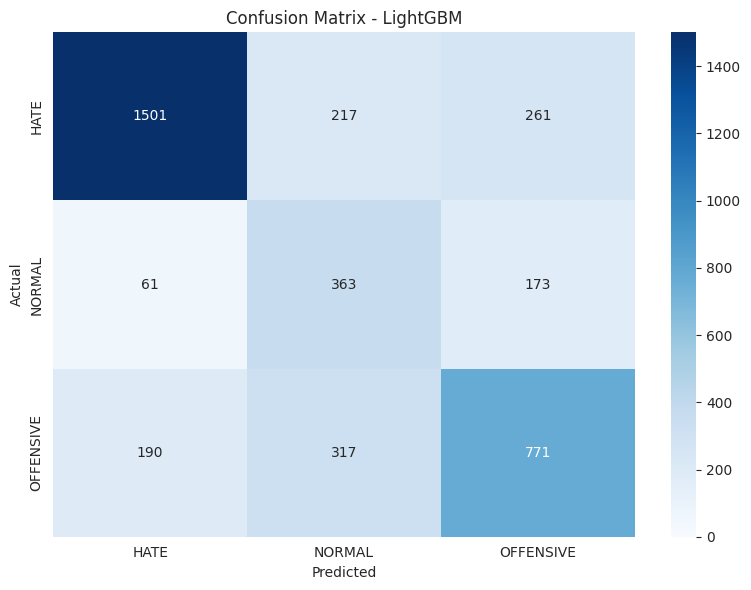


Macro-Averaged AUC: 0.8540
95% CI for Macro-Averaged AUC: [0.8450, 0.8631]
Saved ROC curve to: /content/drive/MyDrive/NLP_Projects/HateSpeech/4o_mini_on_human_majority/LightGBM_roc_curve.png


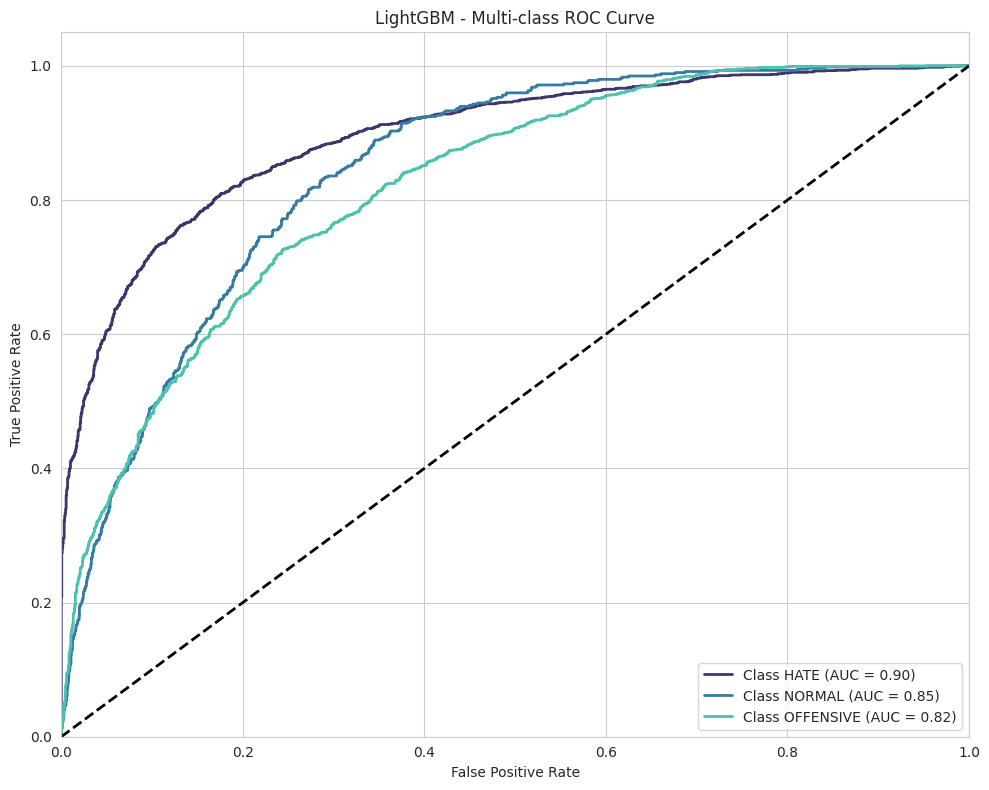

In [ ]:
evaluate_ML_multiclass(LGBM, X_test_ml_tfidf, y_test_ml, model_name = "LightGBM")


### Step 4: Model Interpretation

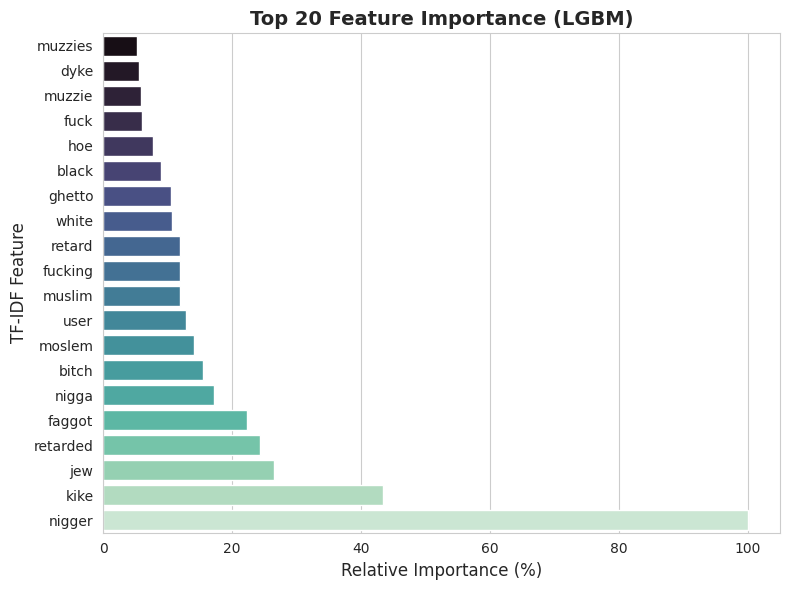

       Feature   Importance  Scaled Importance
6571    nigger  5725.263090         100.000000
5009      kike  2481.271075          43.338988
4656       jew  1513.035111          26.427346
7813  retarded  1393.159006          24.333537
2690    faggot  1279.510008          22.348493
6567     nigga   980.573001          17.127126
763      bitch   882.780643          15.419041
6347    moslem   808.028429          14.113385
9524      user   731.612622          12.778673
6410    muslim   681.771280          11.908121
3022   fucking   678.916400          11.858257
7811    retard   678.664829          11.853863
9782     white   608.686186          10.631585
3146    ghetto   603.272284          10.537023
777      black   511.678773           8.937210
3550       hoe   442.837435           7.734796
3017      fuck   348.452201           6.086222
6433    muzzie   339.628048           5.932095
2333      dyke   317.098684           5.538587
6434   muzzies   297.045902           5.188336


In [ ]:
# --- 1. Check if Model is Fitted ---
if LGBM is not None:

    # --- 2. Get Feature Names and Importances ---

    # Get the feature names (the words) from your fitted TF-IDF vectorizer
    feature_names = tfidf.get_feature_names_out()

    # Get the feature importances from the trained LGBM model
    # (For LGBM, this typically represents "gain" or "split" count)
    feature_importance = LGBM.feature_importances_

    # --- 3. Create and Process Importance DataFrame ---

    # Create a DataFrame to hold features and their scores
    importance_df_lgbm = pd.DataFrame({
        "Feature": feature_names,
        "Importance": feature_importance
    })

    # Normalize importance (rescale to 0–100)
    importance_df_lgbm["Scaled Importance"] = (
        importance_df_lgbm["Importance"] / importance_df_lgbm["Importance"].max()
    ) * 100

    # Sort by importance and get the top 20 features
    top_20_features_lgbm = importance_df_lgbm.sort_values(by = "Importance", ascending = False).head(20)

    # --- 4. Plot the Top 20 Features ---

    plt.figure(figsize = (8, 6))
    sns.set_style("whitegrid")
    sns.barplot(
        x = "Scaled Importance",
        y = "Feature",
        data = top_20_features_lgbm[::-1],  # Reverse [::-1] to plot the most important feature at the top
        palette = "mako"
    )

    # Set titles and labels
    plt.title("Top 20 Feature Importance (LGBM)", fontsize = 14, fontweight = "bold")
    plt.xlabel("Relative Importance (%)", fontsize = 12)
    plt.ylabel("TF-IDF Feature", fontsize = 12)
    plt.xticks(fontsize = 10)
    plt.yticks(fontsize = 10)
    plt.tight_layout()

    # Save a high-resolution version of the plot for your paper
    lgbm_imp_fig_path = os.path.join(DRIVE_PROJECT_PATH, "lgbm_token_importance_top20.png")
    plt.savefig(lgbm_imp_fig_path, dpi = 300)
    plt.show()

    # Optionally print the top 20
    print(top_20_features_lgbm[["Feature", "Importance", "Scaled Importance"]])

else:
    print("No model was trained successfully. Unable to display feature importance.")

## 3.5 Save Predictions for Machine Learning Models

In [ ]:
# df_ml = df_clean.copy() with df_ml["text_ml"] already created
df_test_ml = df_ml[df_ml["split"] == "test"].copy()

# Sanity check: TF–IDF test features
assert X_test_ml_tfidf.shape[0] == len(df_test_ml)

# True labels (strings + encoded)
y_true_str = df_test_ml[LABEL_COLUMN].astype(str).values
y_true_id  = label_encoder.transform(y_true_str)

X_test_vec = X_test_ml_tfidf

# Predictions
lr_pred_str = LR.predict(X_test_vec)
lr_pred_proba = LR.predict_proba(X_test_vec)
svm_pred_str = SVM.predict(X_test_vec)
svm_pred_proba = SVM.predict_proba(X_test_vec)
rf_pred_str = RandomForest.predict(X_test_vec)
rf_pred_proba = RandomForest.predict_proba(X_test_vec)
lgbm_pred_str = LGBM.predict(X_test_vec)
lgbm_pred_proba = LGBM.predict_proba(X_test_vec)

# Ensure consistent class order
class_names = LR.classes_
assert np.array_equal(class_names, SVM.classes_)
assert np.array_equal(class_names, RandomForest.classes_)
assert np.array_equal(class_names, LGBM.classes_)

# ---------- KEY PART: construct id safely ----------
if "id" in df_test_ml.columns:
    # Use existing id column
    df_pred_ml = df_test_ml[["id", TEXT_COLUMN, "text_ml"]].copy()
else:
    # Fall back to index as id, and keep original text column
    df_pred_ml = df_test_ml[[TEXT_COLUMN, "text_ml"]].copy()
    df_pred_ml.insert(0, "id", df_test_ml.index)

df_pred_ml = df_pred_ml.rename(columns = {TEXT_COLUMN: "text_orig"})

# Labels + predictions
df_pred_ml["true_label"] = y_true_str
df_pred_ml["true_label_id"] = y_true_id

df_pred_ml["lr_pred"] = lr_pred_str
df_pred_ml["svm_pred"] = svm_pred_str
df_pred_ml["rf_pred"] = rf_pred_str
df_pred_ml["lgbm_pred"] = lgbm_pred_str

# Probabilities
for i, cls in enumerate(class_names):
    df_pred_ml[f"lr_prob_{cls}"] = lr_pred_proba[:, i]
    df_pred_ml[f"svm_prob_{cls}"] = svm_pred_proba[:, i]
    df_pred_ml[f"rf_prob_{cls}"] = rf_pred_proba[:, i]
    df_pred_ml[f"lgbm_prob_{cls}"] = lgbm_pred_proba[:, i]

df_pred_ml["split"] = "test"

save_path = os.path.join(DRIVE_PROJECT_PATH, "ml_models_predictions.csv")
df_pred_ml.to_csv(save_path, index=False)
print(f"Saved ML predictions to: {save_path}")

Saved ML predictions to: /content/drive/MyDrive/NLP_Projects/HateSpeech/4o_mini_on_human_majority/ml_models_predictions.csv


# 4. DL Models


## 4.0 General Function for ALBERT \& GRU Models

### Define Model Evaluation Functions for GRU, CNN \& ALBERT models

In [ ]:
# --- Helper Function 1: F1 Score Bootstrapping ---
def bootstrap_f1_ci(y_true, y_pred, n_iterations = 1000, average = "weighted"):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    f1_scores = []

    for _ in range(n_iterations):
        indices = resample(np.arange(len(y_true)))
        try:
            f1 = f1_score(y_true[indices], y_pred[indices], average = average)
            f1_scores.append(f1)
        except ValueError:
            continue  # Skip bootstrap sample if it is invalid

    if not f1_scores:
        return np.nan, np.nan, np.nan

    f1_mean = np.mean(f1_scores)
    ci_lower = np.percentile(f1_scores, 2.5)
    ci_upper = np.percentile(f1_scores, 97.5)
    return f1_mean, ci_lower, ci_upper


# --- Helper Function 2: Macro-AUC Bootstrapping ---
# This version correctly takes 1D y_true and 2D y_scores
def bootstrap_auc_ci_multiclass(y_true, y_scores, n_iterations = 1000, average = "macro"):
    auc_scores = []
    y_true = np.array(y_true)
    y_scores = np.array(y_scores)

    for _ in range(n_iterations):
        indices = resample(np.arange(len(y_true)))
        y_true_sample = y_true[indices]
        y_scores_sample = y_scores[indices]

        try:
            # Pass the 1D y_true_sample to roc_auc_score
            auc_sample = roc_auc_score(
                y_true_sample,
                y_scores_sample,
                average = average,
                multi_class = "ovr"
            )
            auc_scores.append(auc_sample)
        except ValueError:
            continue  # Skip bootstrap sample if it is missing a class

    if not auc_scores:
        return np.nan, np.nan, np.nan

    return (
        np.mean(auc_scores),
        np.percentile(auc_scores, 2.5),
        np.percentile(auc_scores, 97.5),
    )


# --- Helper Function 3: Confusion Matrix Plot ---
# This version requires the "labels" (class names) list to be passed
def plot_confusion_matrix(
    y_true,
    y_pred,
    labels,
    model_name = None,
    save_dir = None,
):
    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize = (8, 6))  # Adjusted size for 3 classes
    sns.heatmap(
        conf_matrix,
        annot = True,
        fmt = "d",
        cmap = "Blues",
        xticklabels = labels,
        yticklabels = labels,
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.tight_layout()

    if save_dir is not None and model_name is not None:
        filename = f"{model_name}_confusion_matrix.png"
        save_path = os.path.join(save_dir, filename)
        plt.savefig(save_path, dpi = 300)
        print(f"Saved confusion matrix to: {save_path}")

    plt.show()


# --- Helper Function 4: Multi-class ROC Plot ---
# This version correctly takes the "classes_list" (class names) for binarizing
def plot_multiclass_roc(
    y_true,
    y_score,
    classes_list,
    label_prefix = "Model",
    save_dir = None,
):
    # Binarize using the *actual* list of classes (assumed numeric 0..K-1)
    y_true_bin = label_binarize(y_true, classes = np.arange(len(classes_list)))
    n_classes = len(classes_list)

    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Automatically get n_classes of distinct colors from a colormap
    colors = sns.color_palette("mako", n_classes)

    plt.figure(figsize = (10, 8))

    # Loop over the class names for the plot label
    for i, (class_label, color) in enumerate(zip(classes_list, colors)):
        plt.plot(
            fpr[i],
            tpr[i],
            color = color,
            lw = 2,
            label = f"Class {class_label} (AUC = {roc_auc[i]:.2f})",
        )

    plt.plot([0, 1], [0, 1], "k--", lw = 2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{label_prefix} - Multi-class ROC Curve")
    plt.legend(loc = "lower right")
    plt.tight_layout()

    if save_dir is not None and label_prefix is not None:
        filename = f"{label_prefix}_roc_curve.png"
        save_path = os.path.join(save_dir, filename)
        plt.savefig(save_path, dpi = 300)
        print(f"Saved ROC curve to: {save_path}")

    plt.show()


# --- MAIN EVALUATION WRAPPER (for PyTorch models) ---
def evaluate_pytorch_multiclass(
    model,
    test_loader,
    device,
    label_encoder,
    model_name,
    use_attention_mask = True,
):
    """
    Runs a full evaluation for a fitted PyTorch classifier.
    Handles models with or without an attention mask.
    """

    model.eval()
    model.to(device)

    all_preds = []
    all_probs = []
    all_labels = []

    # Run the evaluation loop
    with torch.no_grad():
        for batch in tqdm(test_loader, desc = f"Evaluating {model_name}"):
            input_ids = batch["input_ids"].to(device)
            labels = batch["label"].to(device)

            # Use the attention mask only if the model needs it
            if use_attention_mask:
                attention_mask = batch["attention_mask"].to(device)
                outputs = model(input_ids = input_ids, attention_mask = attention_mask)
            else:
                outputs = model(input_ids = input_ids)  # For the GRU / CNN

            # Handle both tensor output and HF 'logits' output
            logits = outputs.logits if hasattr(outputs, "logits") else outputs

            # Save probabilities for ALL classes
            probs = torch.softmax(logits, dim = 1)
            # Get the final prediction
            preds = torch.argmax(probs, dim = 1)

            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    # Get the actual string names of your classes (e.g., "normal", "offensive", "hatespeech")
    classes_list = label_encoder.classes_

    print(f"\n--- Evaluation Report: {model_name} ---\n")

    # 1. Classification Report
    print("Classification Report:")
    print(
        classification_report(
            all_labels,
            all_preds,
            target_names = classes_list,
            digits = 4,
        )
    )

    # 2. F1 Score with CI
    f1_mean, f1_ci_low, f1_ci_high = bootstrap_f1_ci(
        all_labels,
        all_preds,
        average = "weighted",
    )
    print(f"Weighted F1 Score: {f1_mean:.4f}")
    print(f"95% CI for F1 Score: [{f1_ci_low:.4f}, {f1_ci_high:.4f}]")

    # 3. Confusion Matrix (now saved)
    plot_confusion_matrix(
        all_labels,
        all_preds,
        labels = classes_list,
        model_name = model_name,
        save_dir = DRIVE_PROJECT_PATH,  # <- use your configured drive path
    )

    # 4. Macro-Averaged AUC with CI
    auc_score, auc_ci_low, auc_ci_high = bootstrap_auc_ci_multiclass(
        all_labels,
        all_probs,
    )
    print(f"\nMacro-Averaged AUC: {auc_score:.4f}")
    print(f"95% CI for Macro-Averaged AUC: [{auc_ci_low:.4f}, {auc_ci_high:.4f}]")

    # 5. Per-Class ROC Curve Plot (now saved)
    plot_multiclass_roc(
        all_labels,
        all_probs,
        classes_list,
        label_prefix = model_name,
        save_dir = DRIVE_PROJECT_PATH,  # <- use your configured drive path
    )

## 4.1 GRU

### 4.1.1 Data Preprocessing

#### Step 1: Copy data for GRU modeling

In [ ]:
df_gru = df_clean.copy()

#### Step 2: Build train/val/test splits for GRU

In [ ]:
# Use the master split directly
df_train_gru = df_gru[df_gru["split"] == "train"].copy()
df_val_gru   = df_gru[df_gru["split"] == "val"].copy()
df_test_gru  = df_gru[df_gru["split"] == "test"].copy()

print("GRU split sizes:",
      len(df_train_gru), len(df_val_gru), len(df_test_gru))

# Texts and labels for GRU (use cleaned master text)
train_texts_gru = df_train_gru[TEXT_COLUMN].tolist()
val_texts_gru = df_val_gru[TEXT_COLUMN].tolist()
test_texts_gru = df_test_gru[TEXT_COLUMN].tolist()

# Labels: pick whichever label column you’re modeling in this panel
train_labels_gru = df_train_gru[LABEL_COLUMN_ENCODED].tolist()
val_labels_gru = df_val_gru[LABEL_COLUMN_ENCODED].tolist()
test_labels_gru = df_test_gru[LABEL_COLUMN_ENCODED].tolist()

GRU split sizes: 11531 3844 3854


#### Step 3: Prepare the data for GRU model

In [ ]:
# Build Vocabulary on Training Data Only
all_train_words = " ".join(train_texts_gru).split()
most_common_words = [word for word, _ in Counter(all_train_words).most_common(VOCAB_SIZE - 1)]
word_to_index = {word: idx + 1 for idx, word in enumerate(most_common_words)}

# Text-to-Sequence Conversion
def text_to_sequence(text, word_to_index, max_len = MAX_TOKEN_LENGTH):
    tokens = text.split()
    sequence = [word_to_index.get(word, 0) for word in tokens]
    return sequence[:max_len]

# Convert text to sequences for train, validation, and test sets
train_sequences_gru = [text_to_sequence(text, word_to_index) for text in train_texts_gru]
val_sequences_gru = [text_to_sequence(text, word_to_index) for text in val_texts_gru]
test_sequences_gru = [text_to_sequence(text, word_to_index) for text in test_texts_gru]

# Pad Sequences
train_sequences_gru = nn.utils.rnn.pad_sequence([torch.tensor(seq) for seq in train_sequences_gru], batch_first = True, padding_value = 0)
val_sequences_gru = nn.utils.rnn.pad_sequence([torch.tensor(seq) for seq in val_sequences_gru], batch_first = True, padding_value = 0)
test_sequences_gru = nn.utils.rnn.pad_sequence([torch.tensor(seq) for seq in test_sequences_gru], batch_first = True, padding_value = 0)

# Convert Labels
train_labels_gru = torch.tensor(train_labels_gru, dtype = torch.long)
val_labels_gru = torch.tensor(val_labels_gru, dtype = torch.long)
test_labels_gru = torch.tensor(test_labels_gru, dtype = torch.long)

# Dataset Class
class SentimentDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": self.texts[idx],
            "label": self.labels[idx]
        }

# Create Datasets and DataLoaders
train_dataset_gru = SentimentDataset(train_sequences_gru, train_labels_gru)
val_dataset_gru = SentimentDataset(val_sequences_gru, val_labels_gru)
test_dataset_gru = SentimentDataset(test_sequences_gru, test_labels_gru)

train_loader_gru = DataLoader(train_dataset_gru, batch_size = BATCH_SIZE, shuffle = True)
val_loader_gru = DataLoader(val_dataset_gru, batch_size = BATCH_SIZE)
test_loader_gru = DataLoader(test_dataset_gru, batch_size = BATCH_SIZE)

### 4.1.2 GRU Modeling

#### Step 1: Define GRU Model

In [ ]:
class GRUSentimentModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
        super(GRUSentimentModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.gru = nn.GRU(embedding_dim, hidden_dim, batch_first = True)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(0.3)

    def forward(self, input_ids):
        embedded = self.embedding(input_ids)
        _, hidden = self.gru(embedded)  # Only last hidden state
        output = self.fc(self.dropout(hidden[-1]))
        return output

#### Step 2: Hyperparameter Tuning

In [ ]:
SEED = 2025
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

MAX_EPOCHS = 20
PATIENCE = 5

# Compute class weights once on train labels
train_labels_np = train_labels_gru.numpy()
class_weights = compute_class_weight(
    class_weight = "balanced",
    classes = np.unique(train_labels_np),
    y=train_labels_np
)
class_weights_tensor = torch.tensor(class_weights, dtype = torch.float32).to(device)

def train_and_evaluate(hyperparams, train_loader, val_loader, vocab_size, output_dim,
                       device, class_weights_tensor, max_epochs = 20, patience = 5):

    embedding_dim = int(hyperparams["embedding_dim"])
    hidden_dim = int(hyperparams["hidden_dim"])
    lr = hyperparams["lr"]

    model = GRUSentimentModel(vocab_size, embedding_dim, hidden_dim, output_dim).to(device)

    criterion = nn.CrossEntropyLoss(weight = class_weights_tensor)
    optimizer = torch.optim.Adam(model.parameters(), lr = lr)

    best_val_f1 = -1.0
    best_val_acc = 0.0
    best_state_dict = None
    epochs_no_improve = 0

    for epoch in range(max_epochs):
        # ---- TRAIN ----
        model.train()
        total_loss = 0.0

        for batch in train_loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["label"].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm = 5.0)
            optimizer.step()

            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)

        # ---- VALIDATE ----
        model.eval()
        val_preds, val_true = [], []
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch["input_ids"].to(device)
                labels = batch["label"].to(device)

                outputs = model(input_ids)
                preds = torch.argmax(outputs, dim = 1)

                val_preds.extend(preds.cpu().numpy())
                val_true.extend(labels.cpu().numpy())

        val_f1 = f1_score(val_true, val_preds, average = "weighted")
        val_acc = accuracy_score(val_true, val_preds)

        print(
            f"Epoch {epoch+1}/{max_epochs} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val F1: {val_f1:.4f} | Val Acc: {val_acc:.4f}"
        )

        # ---- EARLY STOPPING ----
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_val_acc = val_acc
            best_state_dict = model.state_dict()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"No improvement for {patience} epochs. Early stopping at epoch {epoch+1}.")
                break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    return best_val_f1, best_val_acc, model


def random_hyperparameter_tuning(train_loader, val_loader, vocab_size, output_dim,
                                 device, class_weights_tensor, n_iter = N_ITERATIONS):

    param_space = {
        "embedding_dim": (150, 300),
        "hidden_dim": (128, 384),
        "lr": (np.log10(1e-4), np.log10(1e-3)),  # log-uniform
    }

    best_f1 = -1.0
    best_params = None
    best_model = None

    with tqdm(total = n_iter, desc = "Random Search (GRU)", leave = True) as pbar:
        for _ in range(n_iter):
            hyperparams = {
                "embedding_dim": np.random.uniform(*param_space["embedding_dim"]),
                "hidden_dim":   np.random.uniform(*param_space["hidden_dim"]),
                "lr":           10 ** np.random.uniform(*param_space["lr"]),
            }

            f1_val, acc_val, model = train_and_evaluate(
                hyperparams, train_loader, val_loader, vocab_size, output_dim,
                device, class_weights_tensor, max_epochs = MAX_EPOCHS, patience = PATIENCE
            )

            pbar.set_postfix(f1 = f1_val, acc = acc_val)
            pbar.update(1)

            if f1_val > best_f1:
                best_f1 = f1_val
                best_params = hyperparams
                best_model = model

    print(f"\nBest Validation F1 (GRU): {best_f1:.4f}")
    print(f"Best Hyperparameters: {best_params}")

    # Save best model + params
    torch.save(best_model.state_dict(), BEST_GRU_PATH)
    with open(BEST_GRU_PARAMS_PATH, "w") as f:
        json.dump(best_params, f)

    return best_params, best_f1, best_model


# =========================
# 4. Run tuning
# =========================
start_time = time.time()

best_params_gru, best_f1_gru, best_model_gru = random_hyperparameter_tuning(
    train_loader = train_loader_gru, val_loader = val_loader_gru, vocab_size = VOCAB_SIZE, output_dim = NUM_CLASSES,
    device = device, class_weights_tensor = class_weights_tensor, n_iter = N_ITERATIONS
)

end_time = time.time()
print(f"Total GRU tuning time: {end_time - start_time:.2f} seconds")


Random Search (GRU):   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1/20 | Train Loss: 1.0430 | Val F1: 0.5543 | Val Acc: 0.5245
Epoch 2/20 | Train Loss: 0.7809 | Val F1: 0.6780 | Val Acc: 0.6712
Epoch 3/20 | Train Loss: 0.6056 | Val F1: 0.6878 | Val Acc: 0.6813
Epoch 4/20 | Train Loss: 0.4228 | Val F1: 0.6759 | Val Acc: 0.6691
Epoch 5/20 | Train Loss: 0.2427 | Val F1: 0.6802 | Val Acc: 0.6803
Epoch 6/20 | Train Loss: 0.1393 | Val F1: 0.6636 | Val Acc: 0.6647
Epoch 7/20 | Train Loss: 0.0833 | Val F1: 0.6713 | Val Acc: 0.6673


Random Search (GRU):  10%|█         | 1/10 [00:17<02:33, 17.04s/it, acc=0.681, f1=0.688]

Epoch 8/20 | Train Loss: 0.0534 | Val F1: 0.6650 | Val Acc: 0.6699
No improvement for 5 epochs. Early stopping at epoch 8.
Epoch 1/20 | Train Loss: 1.1077 | Val F1: 0.4859 | Val Acc: 0.5359
Epoch 2/20 | Train Loss: 1.0376 | Val F1: 0.5914 | Val Acc: 0.5697
Epoch 3/20 | Train Loss: 0.8663 | Val F1: 0.6142 | Val Acc: 0.5952
Epoch 4/20 | Train Loss: 0.7625 | Val F1: 0.6366 | Val Acc: 0.6241
Epoch 5/20 | Train Loss: 0.6740 | Val F1: 0.6579 | Val Acc: 0.6514
Epoch 6/20 | Train Loss: 0.5839 | Val F1: 0.6460 | Val Acc: 0.6379
Epoch 7/20 | Train Loss: 0.5082 | Val F1: 0.6608 | Val Acc: 0.6561
Epoch 8/20 | Train Loss: 0.4183 | Val F1: 0.6640 | Val Acc: 0.6558
Epoch 9/20 | Train Loss: 0.3480 | Val F1: 0.6578 | Val Acc: 0.6506
Epoch 10/20 | Train Loss: 0.2849 | Val F1: 0.6669 | Val Acc: 0.6626
Epoch 11/20 | Train Loss: 0.2276 | Val F1: 0.6669 | Val Acc: 0.6634
Epoch 12/20 | Train Loss: 0.1831 | Val F1: 0.6630 | Val Acc: 0.6642
Epoch 13/20 | Train Loss: 0.1499 | Val F1: 0.6560 | Val Acc: 0.6457
Ep

Random Search (GRU):  20%|██        | 2/10 [00:50<03:35, 26.90s/it, acc=0.671, f1=0.671]

...

Random Search (GRU):  90%|█████████ | 9/10 [03:46<00:28, 28.32s/it, acc=0.675, f1=0.676]

Epoch 13/20 | Train Loss: 0.0717 | Val F1: 0.6656 | Val Acc: 0.6662
No improvement for 5 epochs. Early stopping at epoch 13.
Epoch 1/20 | Train Loss: 1.1105 | Val F1: 0.3509 | Val Acc: 0.5140
Epoch 2/20 | Train Loss: 1.0938 | Val F1: 0.5077 | Val Acc: 0.5515
Epoch 3/20 | Train Loss: 1.0625 | Val F1: 0.5303 | Val Acc: 0.5377
Epoch 4/20 | Train Loss: 0.9560 | Val F1: 0.6093 | Val Acc: 0.6002
Epoch 5/20 | Train Loss: 0.8490 | Val F1: 0.6284 | Val Acc: 0.6241
Epoch 6/20 | Train Loss: 0.7816 | Val F1: 0.6037 | Val Acc: 0.5809
Epoch 7/20 | Train Loss: 0.7246 | Val F1: 0.6440 | Val Acc: 0.6296
Epoch 8/20 | Train Loss: 0.6663 | Val F1: 0.6549 | Val Acc: 0.6449
Epoch 9/20 | Train Loss: 0.6126 | Val F1: 0.6590 | Val Acc: 0.6472
Epoch 10/20 | Train Loss: 0.5606 | Val F1: 0.6505 | Val Acc: 0.6397
Epoch 11/20 | Train Loss: 0.5101 | Val F1: 0.6563 | Val Acc: 0.6548
Epoch 12/20 | Train Loss: 0.4598 | Val F1: 0.6535 | Val Acc: 0.6452
Epoch 13/20 | Train Loss: 0.4121 | Val F1: 0.6500 | Val Acc: 0.6530


Random Search (GRU): 100%|██████████| 10/10 [04:20<00:00, 26.00s/it, acc=0.647, f1=0.659]

Epoch 14/20 | Train Loss: 0.3707 | Val F1: 0.6561 | Val Acc: 0.6553
No improvement for 5 epochs. Early stopping at epoch 14.

Best Validation F1 (GRU): 0.6902
Best Hyperparameters: {'embedding_dim': 248.60513782065567, 'hidden_dim': 254.1099360016032, 'lr': 0.0009209550194493248}


Total GRU tuning time: 261.87 seconds


#### Step 3: Model Construction (Here we load the best model directly)

In [ ]:
with open(BEST_GRU_PARAMS_PATH, "r") as f:
    loaded_best_params = json.load(f)

embedding_dim_best = int(loaded_best_params["embedding_dim"])
hidden_dim_best = int(loaded_best_params["hidden_dim"])

best_gru = GRUSentimentModel(
    vocab_size = VOCAB_SIZE,
    embedding_dim = embedding_dim_best,
    hidden_dim = hidden_dim_best,
    output_dim = NUM_CLASSES
).to(device)

state_dict = torch.load(BEST_GRU_PATH, map_location = device)
best_gru.load_state_dict(state_dict)

<All keys matched successfully>

#### Step 4: Model Evaluation

Evaluating GRU Model: 100%|██████████| 121/121 [00:00<00:00, 548.99it/s]



--- Evaluation Report: GRU Model ---

Classification Report:
              precision    recall  f1-score   support

        HATE     0.8412    0.7039    0.7664      1979
      NORMAL     0.4502    0.4774    0.4634       597
   OFFENSIVE     0.5534    0.6776    0.6092      1278

    accuracy                         0.6601      3854
   macro avg     0.6149    0.6196    0.6130      3854
weighted avg     0.6852    0.6601    0.6674      3854

Weighted F1 Score: 0.6674
95% CI for F1 Score: [0.6520, 0.6821]
Saved confusion matrix to: /content/drive/MyDrive/NLP_Projects/HateSpeech/4o_mini_on_human_majority/GRU Model_confusion_matrix.png


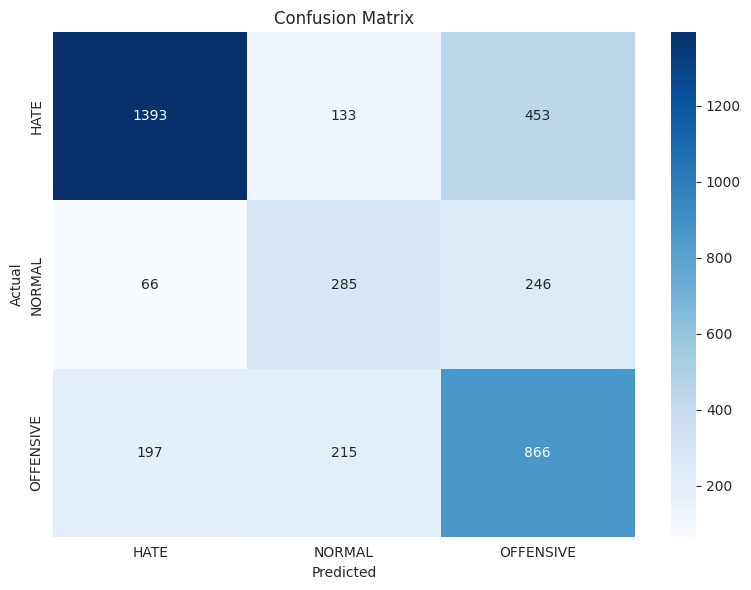


Macro-Averaged AUC: 0.8264
95% CI for Macro-Averaged AUC: [0.8149, 0.8364]
Saved ROC curve to: /content/drive/MyDrive/NLP_Projects/HateSpeech/4o_mini_on_human_majority/GRU Model_roc_curve.png


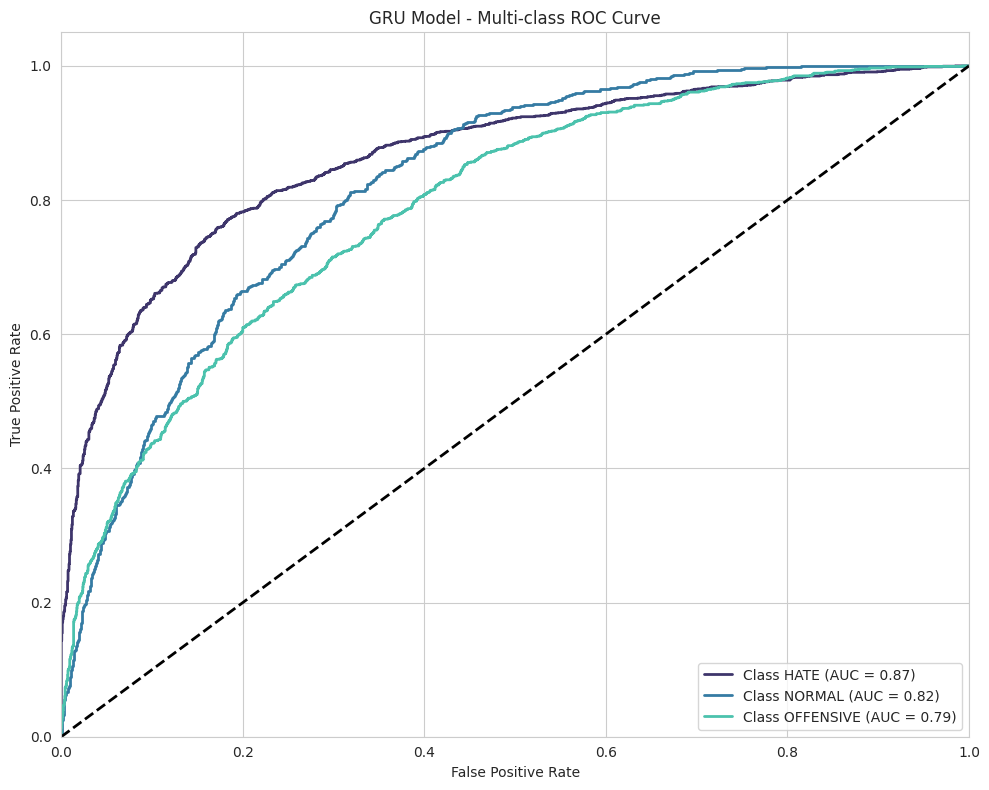

In [ ]:
# Evaluate the best model on the test set
best_gru.eval()
test_predictions_gru, test_labels_gru = [], []
test_probabilities_gru = []

with torch.no_grad():
    for batch in test_loader_gru:
        input_ids = batch["input_ids"].to(device)
        labels = batch["label"].to(device)

        # Forward pass
        outputs = best_gru(input_ids)

        # Apply softmax to get probabilities for all classes
        probs = torch.softmax(outputs, dim = 1)
        test_probabilities_gru.extend(probs.cpu().numpy())  # Collect probabilities for all classes

        # Collect predictions and labels (unchanged)
        preds = torch.argmax(probs, dim = 1)
        test_predictions_gru.extend(preds.cpu().numpy())
        test_labels_gru.extend(labels.cpu().numpy())

evaluate_pytorch_multiclass(
    model = best_gru,
    test_loader = test_loader_gru,
    device = device,
    label_encoder = label_encoder,
    model_name = "GRU Model",
    use_attention_mask = False  # <-- This is the key part for the GRU
)

#### Step 5: Model Interpretation

Example vocab mappings (idx2word): [(1, 'the'), (2, 'a'), (3, 'to'), (4, 'and'), (5, 'i'), (6, 'user'), (7, 'you'), (8, 'of'), (9, 'is'), (10, 'not')]
GRU validation tensor shape: torch.Size([3844, 56])
Baseline weighted F1 on GRU validation: 0.6713
Will compute permutation importance for these token IDs (most frequent):
[ 1  2  3  4  5  6  7  8  9 10 11 13 12 14 15 16 17 18 21 25] ...
Token ID 1 ('the'): perturbed F1=0.6669, ΔF1=0.0044
Token ID 2 ('a'): perturbed F1=0.6720, ΔF1=-0.0007
Token ID 3 ('to'): perturbed F1=0.6693, ΔF1=0.0020
Token ID 4 ('and'): perturbed F1=0.6721, ΔF1=-0.0008
Token ID 5 ('i'): perturbed F1=0.6701, ΔF1=0.0012
Token ID 6 ('user'): perturbed F1=0.6726, ΔF1=-0.0013
Token ID 7 ('you'): perturbed F1=0.6688, ΔF1=0.0025
Token ID 8 ('of'): perturbed F1=0.6713, ΔF1=0.0000
Token ID 9 ('is'): perturbed F1=0.6713, ΔF1=0.0001
Token ID 10 ('not'): perturbed F1=0.6710, ΔF1=0.0003
Token ID 11 ('in'): perturbed F1=0.6720, ΔF1=-0.0006
Token ID 13 ('that'): perturbed F1=0.670

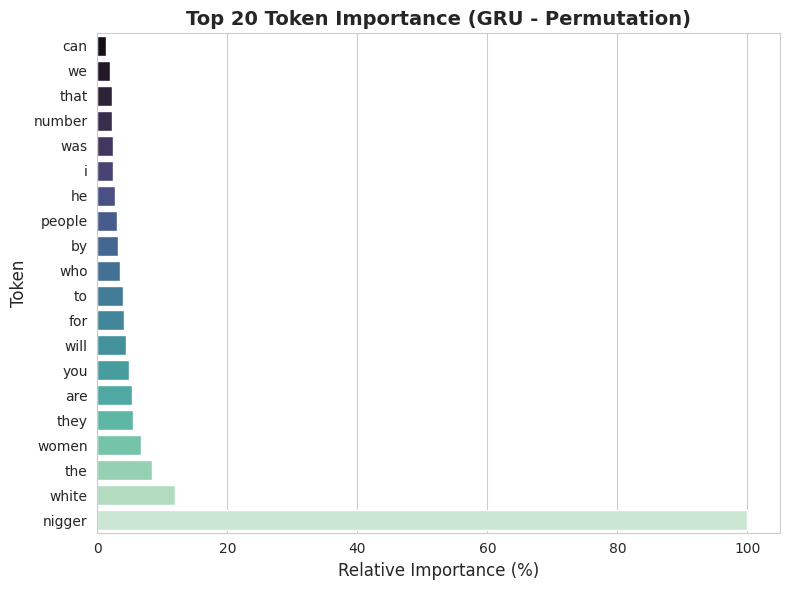

In [ ]:
# ==============================
# 1. Config and vocab mapping
# ==============================

# Your vocab dict: {word: index}
# If your dict has a different name, change this line accordingly.
vocab_dict = word_to_index

# Build reverse lookup: index -> word
idx2word = {idx: word for word, idx in vocab_dict.items()}
print("Example vocab mappings (idx2word):", list(idx2word.items())[:10])

# IMPORTANT: set this to your actual PAD index (often 0)
PAD_IDX = 0

# Number of tokens to evaluate for permutation importance
TOP_TOKENS = 50

# ==============================
# 2. Collect validation inputs / labels for GRU
# ==============================

best_gru.eval()
best_gru.to(device)

val_input_ids_list = []
val_labels_list = []

with torch.no_grad():
    for batch in val_loader_gru:
        val_input_ids_list.append(batch["input_ids"])
        val_labels_list.append(batch["label"])

val_input_ids = torch.cat(val_input_ids_list, dim = 0)   # [N, L]
val_labels = torch.cat(val_labels_list, dim = 0)      # [N]
val_labels_np = val_labels.cpu().numpy()

print("GRU validation tensor shape:", val_input_ids.shape)

# ==============================
# 3. Helper: run GRU on a given tensor
# ==============================

def gru_preds_from_ids(input_ids_tensor):
    """
    Given a [N, L] tensor of token IDs, return numpy array of predictions
    from best_gru.
    """
    with torch.no_grad():
        logits = best_gru(input_ids_tensor.to(device))
        # If some wrapper returns an object with .logits, handle that:
        if hasattr(logits, "logits"):
            logits = logits.logits
        preds = torch.argmax(logits, dim = 1).cpu().numpy()
    return preds

# Baseline F1 on unperturbed validation data
baseline_preds_gru = gru_preds_from_ids(val_input_ids)
baseline_f1_gru    = f1_score(val_labels_np, baseline_preds_gru, average="weighted")

print(f"Baseline weighted F1 on GRU validation: {baseline_f1_gru:.4f}")

# ==============================
# 4. Choose which tokens to perturb (most frequent in validation)
# ==============================

vals_np = val_input_ids.cpu().numpy().ravel()
unique_ids, counts = np.unique(vals_np, return_counts=True)

# Sort by frequency (descending)
order = np.argsort(-counts)
unique_ids = unique_ids[order]
counts = counts[order]

# Drop PAD from candidates
mask_not_pad = unique_ids != PAD_IDX
unique_ids = unique_ids[mask_not_pad]
counts = counts[mask_not_pad]

candidate_token_ids = unique_ids[:TOP_TOKENS]
print("Will compute permutation importance for these token IDs (most frequent):")
print(candidate_token_ids[:20], "...")

# ==============================
# 5. Permutation importance by masking tokens
# ==============================

token_importances_gru = []  # list of dicts for DataFrame

for tok_id in candidate_token_ids:
    tok_id = int(tok_id)

    # Where does this token appear in validation?
    mask = (val_input_ids == tok_id)

    # If it never appears (edge case), skip
    if not mask.any():
        continue

    # Make a perturbed copy: replace this token with PAD everywhere
    perturbed_ids = val_input_ids.clone()
    perturbed_ids[mask] = PAD_IDX

    # Compute F1 with perturbed inputs
    perturbed_preds = gru_preds_from_ids(perturbed_ids)
    perturbed_f1 = f1_score(val_labels_np, perturbed_preds, average="weighted")

    delta_f1 = baseline_f1_gru - perturbed_f1

    # Map ID -> word, fallback to <tok_id> if unseen
    token_str = idx2word.get(tok_id, f"<tok_{tok_id}>")

    token_importances_gru.append({
        "Feature": token_str,
        "Importance": delta_f1
    })

    print(f"Token ID {tok_id} ('{token_str}'): "
          f"perturbed F1={perturbed_f1:.4f}, ΔF1={delta_f1:.4f}")

print("\nComputed permutation importance for", len(token_importances_gru), "tokens (GRU).")

# ==============================
# 6. Build DataFrame and plot top 20
# ==============================

importance_df_gru = pd.DataFrame(token_importances_gru)

# Clip any tiny negatives to 0
importance_df_gru["Importance"] = importance_df_gru["Importance"].clip(lower=0)

# Normalize to 0–100 for "Relative Importance (%)"
if importance_df_gru["Importance"].max() > 0:
    importance_df_gru["Scaled Importance"] = (
        importance_df_gru["Importance"] / importance_df_gru["Importance"].max()
    ) * 100
else:
    importance_df_gru["Scaled Importance"] = 0.0

# Sort and take top 20 tokens
top_20_gru = importance_df_gru.sort_values(
    by = "Importance", ascending = False
).head(20)

print("\nTop 20 token importances for GRU:")
print(top_20_gru[["Feature", "Importance", "Scaled Importance"]])

# Plot (same style as LR and CNN)
plt.figure(figsize=(8, 6))
sns.set_style("whitegrid")
sns.barplot(
    x = "Scaled Importance",
    y = "Feature",
    data = top_20_gru[::-1],   # reverse so most important is at top
    orient = "h",
    palette = "mako"
)

plt.title("Top 20 Token Importance (GRU - Permutation)", fontsize = 14, fontweight = "bold")
plt.xlabel("Relative Importance (%)", fontsize = 12)
plt.ylabel("Token", fontsize = 12)
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)
plt.tight_layout()

gru_imp_fig_path = os.path.join(DRIVE_PROJECT_PATH, "gru_token_importance_top20.png")
plt.savefig(gru_imp_fig_path, dpi = 300)
plt.show()

## 4.2 CNN

### 4.2.1 Data Preprocessing

#### Step 1: Copy data for CNN modeling

In [ ]:
df_cnn = df_clean.copy()

#### Step 2: Build train/val/test splits for CNN

In [ ]:
# Use the master split directly
df_train_cnn = df_cnn[df_cnn["split"]=="train"].copy()
df_val_cnn   = df_cnn[df_cnn["split"]=="val"].copy()
df_test_cnn  = df_cnn[df_cnn["split"]=="test"].copy()

print("CNN split sizes:",
      len(df_train_cnn), len(df_val_cnn), len(df_test_cnn))

# Texts and labels for CNN (use cleaned master text)
train_texts_cnn = df_train_cnn[TEXT_COLUMN].tolist()
train_labels_cnn = df_train_cnn[LABEL_COLUMN_ENCODED].tolist()

val_texts_cnn = df_val_cnn[TEXT_COLUMN].tolist()
val_labels_cnn = df_val_cnn[LABEL_COLUMN_ENCODED].tolist()

test_texts_cnn = df_test_cnn[TEXT_COLUMN].tolist()
test_labels_cnn = df_test_cnn[LABEL_COLUMN_ENCODED].tolist()

CNN split sizes: 11531 3844 3854


#### Step 3: Prepare the data for GRU model

In [ ]:
# Build vocabulary on training data only
all_train_words_cnn = " ".join(train_texts_cnn).split()
most_common_words_cnn = [w for w, _ in Counter(all_train_words_cnn).most_common(VOCAB_SIZE - 1)]
word_to_index_cnn = {word: idx + 1 for idx, word in enumerate(most_common_words_cnn)}  # 0 = PAD

def text_to_sequence_cnn(text, word_to_index, max_len=MAX_TOKEN_LENGTH):
    tokens = text.split()
    seq = [word_to_index.get(tok, 0) for tok in tokens]
    return seq[:max_len]

# Convert text to sequences
train_sequences_cnn = [text_to_sequence_cnn(t, word_to_index_cnn) for t in train_texts_cnn]
val_sequences_cnn = [text_to_sequence_cnn(t, word_to_index_cnn) for t in val_texts_cnn]
test_sequences_cnn = [text_to_sequence_cnn(t, word_to_index_cnn) for t in test_texts_cnn]

# Pad sequences
def pad_sequences(seqs):
    return nn.utils.rnn.pad_sequence(
        [torch.tensor(s, dtype = torch.long) for s in seqs],
        batch_first = True,
        padding_value = 0
    )

train_sequences_cnn = pad_sequences(train_sequences_cnn)
val_sequences_cnn = pad_sequences(val_sequences_cnn)
test_sequences_cnn = pad_sequences(test_sequences_cnn)

# Convert labels to tensors
train_labels_cnn = torch.tensor(train_labels_cnn, dtype = torch.long)
val_labels_cnn = torch.tensor(val_labels_cnn, dtype = torch.long)
test_labels_cnn = torch.tensor(test_labels_cnn, dtype = torch.long)

# Create Datasets and DataLoaders
class SentimentDatasetCNN(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": self.texts[idx],
            "label": self.labels[idx]
        }

train_dataset_cnn = SentimentDatasetCNN(train_sequences_cnn, train_labels_cnn)
val_dataset_cnn = SentimentDatasetCNN(val_sequences_cnn, val_labels_cnn)
test_dataset_cnn = SentimentDatasetCNN(test_sequences_cnn, test_labels_cnn)

train_loader_cnn = DataLoader(train_dataset_cnn, batch_size = BATCH_SIZE, shuffle = True)
val_loader_cnn = DataLoader(val_dataset_cnn, batch_size = BATCH_SIZE, shuffle = False)
test_loader_cnn = DataLoader(test_dataset_cnn, batch_size = BATCH_SIZE, shuffle = False)

### 4.2.2 CNN Modeling

#### Step 1: Define CNN Model

In [ ]:
class CNNSentimentModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, num_filters, output_dim,
                 kernel_sizes=(3, 4, 5), dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        self.convs = nn.ModuleList([
            nn.Conv1d(
                in_channels=embedding_dim,
                out_channels=num_filters,
                kernel_size=k
            ) for k in kernel_sizes
        ])

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), output_dim)

    def forward(self, input_ids):
        # input_ids: [B, T]
        embedded = self.embedding(input_ids)          # [B, T, E]
        embedded = embedded.permute(0, 2, 1)          # [B, E, T]

        conv_outs = []
        for conv in self.convs:
            x = conv(embedded)                        # [B, F, T']
            x = torch.relu(x)
            x = torch.max_pool1d(x, kernel_size=x.size(2))  # [B, F, 1]
            x = x.squeeze(2)                          # [B, F]
            conv_outs.append(x)

        cat = torch.cat(conv_outs, dim = 1)             # [B, F * len(kernel_sizes)]
        out = self.fc(self.dropout(cat))              # [B, C]
        return out

#### Step 2: Hyperparameter Tuning

In [ ]:
SEED = 2025
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

MAX_EPOCHS = 20
PATIENCE = 5

# Class weights from training labels
train_labels_np_cnn = train_labels_cnn.numpy()
class_weights_cnn = compute_class_weight(
    class_weight = "balanced",
    classes = np.unique(train_labels_np_cnn),
    y=train_labels_np_cnn
)
class_weights_tensor_cnn = torch.tensor(class_weights_cnn, dtype = torch.float32).to(device)

def train_and_evaluate_cnn(hyperparams, train_loader, val_loader, vocab_size, output_dim,
                           device, class_weights_tensor, max_epochs = 20, patience = 5):

    embedding_dim = int(hyperparams["embedding_dim"])
    num_filters = int(hyperparams["num_filters"])
    lr = hyperparams["lr"]

    model = CNNSentimentModel(
        vocab_size = vocab_size,
        embedding_dim = embedding_dim,
        num_filters = num_filters,
        output_dim = output_dim,
        kernel_sizes = (3, 4, 5),
        dropout = 0.5
    ).to(device)

    criterion = nn.CrossEntropyLoss(weight = class_weights_tensor)
    optimizer = torch.optim.Adam(model.parameters(), lr = lr)

    best_val_f1 = -1.0
    best_val_acc = 0.0
    best_state_dict = None
    epochs_no_improve = 0

    for epoch in range(max_epochs):
        # ----- TRAIN -----
        model.train()
        total_loss = 0.0

        for batch in train_loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["label"].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm = 5.0)
            optimizer.step()

            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)

        # ----- VALIDATE -----
        model.eval()
        val_preds, val_true = [], []
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch["input_ids"].to(device)
                labels = batch["label"].to(device)

                outputs = model(input_ids)
                preds = torch.argmax(outputs, dim = 1)

                val_preds.extend(preds.cpu().numpy())
                val_true.extend(labels.cpu().numpy())

        val_f1 = f1_score(val_true, val_preds, average = "weighted")
        val_acc = accuracy_score(val_true, val_preds)

        print(
            f"[CNN] Epoch {epoch+1}/{max_epochs} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val F1: {val_f1:.4f} | Val Acc: {val_acc:.4f}"
        )

        # ----- EARLY STOPPING -----
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_val_acc = val_acc
            best_state_dict = model.state_dict()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"[CNN] No improvement for {patience} epochs. Early stopping at epoch {epoch+1}.")
                break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    return best_val_f1, best_val_acc, model


# Random search for CNN
def random_hyperparameter_tuning_cnn(train_loader, val_loader, vocab_size, output_dim,
                                     device, class_weights_tensor, n_iter = N_ITERATIONS):

    param_space = {
        "embedding_dim": (150, 300),     # uniform
        "num_filters":  (80, 200),       # filters per kernel size
        "lr": (np.log10(1e-4), np.log10(1e-3)),  # log-uniform
    }

    best_f1 = -1.0
    best_params = None
    best_model = None

    with tqdm(total=n_iter, desc = "Random Search (CNN)", leave = True) as pbar:
        for _ in range(n_iter):
            hyperparams = {
                "embedding_dim": np.random.uniform(*param_space["embedding_dim"]),
                "num_filters": np.random.uniform(*param_space["num_filters"]),
                "lr": 10 ** np.random.uniform(*param_space["lr"]),
            }

            f1_val, acc_val, model = train_and_evaluate_cnn(
                hyperparams, train_loader, val_loader, vocab_size, output_dim,
                device, class_weights_tensor, max_epochs = MAX_EPOCHS, patience = PATIENCE
            )

            pbar.set_postfix(f1 = f1_val, acc = acc_val)
            pbar.update(1)

            if f1_val > best_f1:
                best_f1 = f1_val
                best_params = hyperparams
                best_model = model

    print(f"\n[CNN] Best Validation F1: {best_f1:.4f}")
    print(f"[CNN] Best Hyperparameters: {best_params}")

    # Save best model + params
    torch.save(best_model.state_dict(), BEST_CNN_PATH)
    with open(BEST_CNN_PARAMS_PATH, "w") as f:
        json.dump(best_params, f)

    return best_params, best_f1, best_model

# Run CNN tuning
start_time = time.time()

best_params_cnn, best_f1_cnn, best_model_cnn = random_hyperparameter_tuning_cnn(
    train_loader = train_loader_cnn, val_loader = val_loader_cnn, vocab_size = VOCAB_SIZE, output_dim = NUM_CLASSES,
    device = device, class_weights_tensor = class_weights_tensor_cnn,
    n_iter = N_ITERATIONS
)

end_time = time.time()
print(f"Total CNN tuning time: {end_time - start_time:.2f} seconds")

Random Search (CNN):   0%|          | 0/10 [00:00<?, ?it/s]

[CNN] Epoch 1/20 | Train Loss: 1.0443 | Val F1: 0.6162 | Val Acc: 0.6236
[CNN] Epoch 2/20 | Train Loss: 0.7953 | Val F1: 0.6406 | Val Acc: 0.6301
[CNN] Epoch 3/20 | Train Loss: 0.6572 | Val F1: 0.6461 | Val Acc: 0.6322
[CNN] Epoch 4/20 | Train Loss: 0.5383 | Val F1: 0.6811 | Val Acc: 0.6714
[CNN] Epoch 5/20 | Train Loss: 0.4370 | Val F1: 0.6872 | Val Acc: 0.6886
[CNN] Epoch 6/20 | Train Loss: 0.3472 | Val F1: 0.6751 | Val Acc: 0.6878
[CNN] Epoch 7/20 | Train Loss: 0.2733 | Val F1: 0.6819 | Val Acc: 0.6779
[CNN] Epoch 8/20 | Train Loss: 0.2149 | Val F1: 0.6879 | Val Acc: 0.6831
[CNN] Epoch 9/20 | Train Loss: 0.1558 | Val F1: 0.6854 | Val Acc: 0.6790
[CNN] Epoch 10/20 | Train Loss: 0.1475 | Val F1: 0.6825 | Val Acc: 0.6816
[CNN] Epoch 11/20 | Train Loss: 0.1100 | Val F1: 0.6796 | Val Acc: 0.6740
[CNN] Epoch 12/20 | Train Loss: 0.1020 | Val F1: 0.6815 | Val Acc: 0.6902


Random Search (CNN):  10%|█         | 1/10 [00:22<03:23, 22.66s/it, acc=0.683, f1=0.688]

[CNN] Epoch 13/20 | Train Loss: 0.0878 | Val F1: 0.6812 | Val Acc: 0.6761
[CNN] No improvement for 5 epochs. Early stopping at epoch 13.
[CNN] Epoch 1/20 | Train Loss: 1.1094 | Val F1: 0.6085 | Val Acc: 0.5986
[CNN] Epoch 2/20 | Train Loss: 0.8915 | Val F1: 0.6302 | Val Acc: 0.6119
[CNN] Epoch 3/20 | Train Loss: 0.7748 | Val F1: 0.6385 | Val Acc: 0.6223
[CNN] Epoch 4/20 | Train Loss: 0.6870 | Val F1: 0.6613 | Val Acc: 0.6501
[CNN] Epoch 5/20 | Train Loss: 0.6148 | Val F1: 0.6695 | Val Acc: 0.6589
[CNN] Epoch 6/20 | Train Loss: 0.5606 | Val F1: 0.6770 | Val Acc: 0.6727
[CNN] Epoch 7/20 | Train Loss: 0.4905 | Val F1: 0.6763 | Val Acc: 0.6678
[CNN] Epoch 8/20 | Train Loss: 0.4429 | Val F1: 0.6828 | Val Acc: 0.6772
[CNN] Epoch 9/20 | Train Loss: 0.3956 | Val F1: 0.6802 | Val Acc: 0.6751
[CNN] Epoch 10/20 | Train Loss: 0.3686 | Val F1: 0.6810 | Val Acc: 0.6766
[CNN] Epoch 11/20 | Train Loss: 0.3284 | Val F1: 0.6806 | Val Acc: 0.6779
[CNN] Epoch 12/20 | Train Loss: 0.3011 | Val F1: 0.6838 | 

Random Search (CNN):  20%|██        | 2/10 [04:14<19:25, 145.63s/it, acc=0.691, f1=0.691]

...

Random Search (CNN):  90%|█████████ | 9/10 [23:11<02:30, 150.33s/it, acc=0.684, f1=0.687]

[CNN] Epoch 18/20 | Train Loss: 0.0747 | Val F1: 0.6816 | Val Acc: 0.6834
[CNN] No improvement for 5 epochs. Early stopping at epoch 18.
[CNN] Epoch 1/20 | Train Loss: 1.1428 | Val F1: 0.5584 | Val Acc: 0.5520
[CNN] Epoch 2/20 | Train Loss: 0.9785 | Val F1: 0.6163 | Val Acc: 0.6145
[CNN] Epoch 3/20 | Train Loss: 0.8729 | Val F1: 0.6285 | Val Acc: 0.6204
[CNN] Epoch 4/20 | Train Loss: 0.8101 | Val F1: 0.6418 | Val Acc: 0.6324
[CNN] Epoch 5/20 | Train Loss: 0.7453 | Val F1: 0.6404 | Val Acc: 0.6259
[CNN] Epoch 6/20 | Train Loss: 0.6960 | Val F1: 0.6549 | Val Acc: 0.6532
[CNN] Epoch 7/20 | Train Loss: 0.6512 | Val F1: 0.6573 | Val Acc: 0.6452
[CNN] Epoch 8/20 | Train Loss: 0.6151 | Val F1: 0.6574 | Val Acc: 0.6441
[CNN] Epoch 9/20 | Train Loss: 0.5820 | Val F1: 0.6644 | Val Acc: 0.6530
[CNN] Epoch 10/20 | Train Loss: 0.5401 | Val F1: 0.6654 | Val Acc: 0.6561
[CNN] Epoch 11/20 | Train Loss: 0.5161 | Val F1: 0.6684 | Val Acc: 0.6582
[CNN] Epoch 12/20 | Train Loss: 0.4784 | Val F1: 0.6700 | 

Random Search (CNN): 100%|██████████| 10/10 [26:50<00:00, 161.07s/it, acc=0.681, f1=0.684]

[CNN] Epoch 20/20 | Train Loss: 0.3042 | Val F1: 0.6836 | Val Acc: 0.6808

[CNN] Best Validation F1: 0.6983
[CNN] Best Hyperparameters: {'embedding_dim': 248.60513782065567, 'num_filters': 139.11403250075148, 'lr': 0.0009209550194493248}


Total CNN tuning time: 1613.11 seconds


#### Step 3: Model Construction (Here we load the best model directly)

In [ ]:
with open(BEST_CNN_PARAMS_PATH, "r") as f:
    loaded_best_params_cnn = json.load(f)

embedding_dim_best_cnn = int(loaded_best_params_cnn["embedding_dim"])
num_filters_best_cnn = int(loaded_best_params_cnn["num_filters"])

best_cnn = CNNSentimentModel(
    vocab_size = VOCAB_SIZE,
    embedding_dim = embedding_dim_best_cnn,
    num_filters = num_filters_best_cnn,
    output_dim = NUM_CLASSES,
    kernel_sizes = (3, 4, 5),
    dropout = 0.5
).to(device)

#### Step 4: Model Evaluation

Evaluating CNN Model: 100%|██████████| 121/121 [00:00<00:00, 648.18it/s]



--- Evaluation Report: CNN Model ---

Classification Report:
              precision    recall  f1-score   support

        HATE     0.7778    0.8312    0.8036      1979
      NORMAL     0.4701    0.4472    0.4584       597
   OFFENSIVE     0.6234    0.5712    0.5962      1278

    accuracy                         0.6855      3854
   macro avg     0.6237    0.6166    0.6194      3854
weighted avg     0.6789    0.6855    0.6813      3854

Weighted F1 Score: 0.6810
95% CI for F1 Score: [0.6659, 0.6962]
Saved confusion matrix to: /content/drive/MyDrive/NLP_Projects/HateSpeech/4o_mini_on_human_majority/CNN Model_confusion_matrix.png


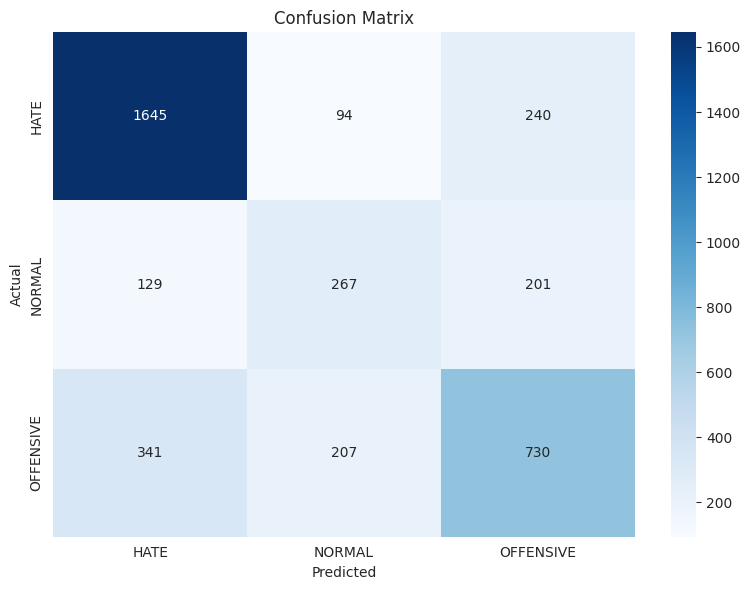


Macro-Averaged AUC: 0.8356
95% CI for Macro-Averaged AUC: [0.8251, 0.8456]
Saved ROC curve to: /content/drive/MyDrive/NLP_Projects/HateSpeech/4o_mini_on_human_majority/CNN Model_roc_curve.png


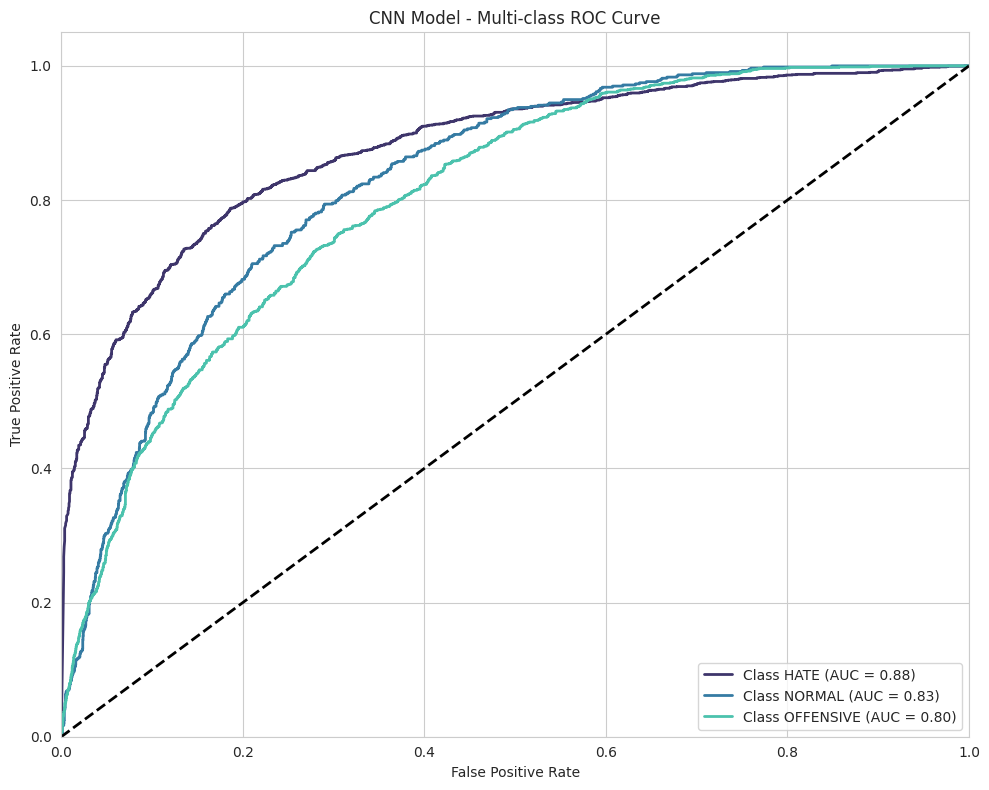

In [ ]:
state_dict_cnn = torch.load(BEST_CNN_PATH, map_location = device)
best_cnn.load_state_dict(state_dict_cnn)
best_cnn.eval()

test_predictions_cnn = []
test_labels_true_cnn = []
test_probabilities_cnn = []

with torch.no_grad():
    for batch in test_loader_cnn:
        input_ids = batch["input_ids"].to(device)
        labels = batch["label"].to(device)

        logits = best_cnn(input_ids)
        probs = torch.softmax(logits, dim = 1)

        test_probabilities_cnn.extend(probs.cpu().numpy())
        preds = torch.argmax(probs, dim = 1)

        test_predictions_cnn.extend(preds.cpu().numpy())
        test_labels_true_cnn.extend(labels.cpu().numpy())

# Use your existing helper for reporting
evaluate_pytorch_multiclass(
    model = best_cnn,
    test_loader = test_loader_cnn,
    device = device,
    label_encoder = label_encoder,
    model_name = "CNN Model",
    use_attention_mask = False
)

#### Step 5: Model Interpretation

Example vocab mappings (idx2word): [(1, 'the'), (2, 'a'), (3, 'to'), (4, 'and'), (5, 'i'), (6, 'user'), (7, 'you'), (8, 'of'), (9, 'is'), (10, 'not')]
CNN validation tensor shape: torch.Size([3844, 56])
Baseline weighted F1 on CNN validation: 0.6886
Will compute permutation importance for these token IDs (most frequent):
[ 1  2  3  4  5  6  7  8  9 10 11 13 12 14 15 16 17 18 21 25] ...
Token ID 1 ('the'): perturbed F1=0.6878, ΔF1=0.0008
Token ID 2 ('a'): perturbed F1=0.6863, ΔF1=0.0023
Token ID 3 ('to'): perturbed F1=0.6894, ΔF1=-0.0007
Token ID 4 ('and'): perturbed F1=0.6894, ΔF1=-0.0007
Token ID 5 ('i'): perturbed F1=0.6869, ΔF1=0.0017
Token ID 6 ('user'): perturbed F1=0.6900, ΔF1=-0.0013
Token ID 7 ('you'): perturbed F1=0.6871, ΔF1=0.0015
Token ID 8 ('of'): perturbed F1=0.6885, ΔF1=0.0001
Token ID 9 ('is'): perturbed F1=0.6874, ΔF1=0.0013
Token ID 10 ('not'): perturbed F1=0.6873, ΔF1=0.0013
Token ID 11 ('in'): perturbed F1=0.6885, ΔF1=0.0002
Token ID 13 ('that'): perturbed F1=0.6892

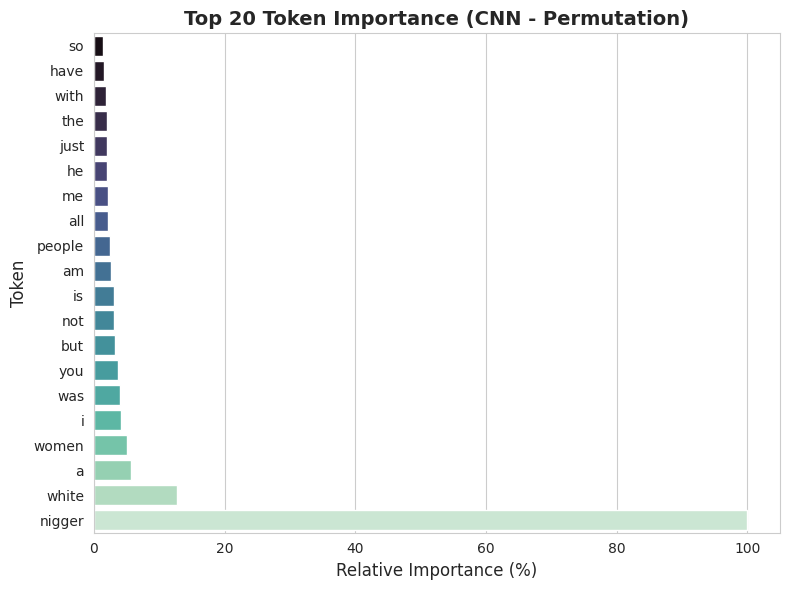

In [ ]:
# ==============================
# 1. Config and vocab mapping
# ==============================

# Your vocab dict: {word: index}
# If your dict has a different name, change this line accordingly.
vocab_dict = word_to_index

# Build reverse lookup: index -> word
idx2word = {idx: word for word, idx in vocab_dict.items()}
print("Example vocab mappings (idx2word):", list(idx2word.items())[:10])

# IMPORTANT: set this to your actual PAD index (often 0)
PAD_IDX = 0

# Number of tokens to evaluate for permutation importance
TOP_TOKENS = 50

# ==============================
# 2. Collect validation inputs / labels for CNN
# ==============================

best_cnn.eval()
best_cnn.to(device)

val_input_ids_list = []
val_labels_list = []

with torch.no_grad():
    for batch in val_loader_cnn:
        val_input_ids_list.append(batch["input_ids"])
        val_labels_list.append(batch["label"])

val_input_ids = torch.cat(val_input_ids_list, dim = 0)   # [N, L]
val_labels = torch.cat(val_labels_list, dim = 0)      # [N]
val_labels_np = val_labels.cpu().numpy()

print("CNN validation tensor shape:", val_input_ids.shape)

# ==============================
# 3. Helper: run CNN on a given tensor
# ==============================

def cnn_preds_from_ids(input_ids_tensor):
    """
    Given a [N, L] tensor of token IDs, return numpy array of predictions
    from best_cnn.
    """
    with torch.no_grad():
        logits = best_cnn(input_ids_tensor.to(device))
        # In case your CNN wrapper returns an object with .logits, handle that:
        if hasattr(logits, "logits"):
            logits = logits.logits
        preds = torch.argmax(logits, dim = 1).cpu().numpy()
    return preds

# Baseline F1 on unperturbed validation data
baseline_preds_cnn = cnn_preds_from_ids(val_input_ids)
baseline_f1_cnn = f1_score(val_labels_np, baseline_preds_cnn, average="weighted")

print(f"Baseline weighted F1 on CNN validation: {baseline_f1_cnn:.4f}")

# ==============================
# 4. Choose which tokens to perturb (most frequent in validation)
# ==============================

vals_np = val_input_ids.cpu().numpy().ravel()
unique_ids, counts = np.unique(vals_np, return_counts=True)

# Sort by frequency (descending)
order = np.argsort(-counts)
unique_ids = unique_ids[order]
counts = counts[order]

# Drop PAD from candidates
mask_not_pad = unique_ids != PAD_IDX
unique_ids = unique_ids[mask_not_pad]
counts = counts[mask_not_pad]

candidate_token_ids = unique_ids[:TOP_TOKENS]
print("Will compute permutation importance for these token IDs (most frequent):")
print(candidate_token_ids[:20], "...")

# ==============================
# 5. Permutation importance by masking tokens
# ==============================

token_importances = []  # list of dicts for DataFrame

for tok_id in candidate_token_ids:
    tok_id = int(tok_id)

    # Where does this token appear in validation?
    mask = (val_input_ids == tok_id)

    # If it never appears (edge case), skip
    if not mask.any():
        continue

    # Make a perturbed copy: replace this token with PAD everywhere
    perturbed_ids = val_input_ids.clone()
    perturbed_ids[mask] = PAD_IDX

    # Compute F1 with perturbed inputs
    perturbed_preds = cnn_preds_from_ids(perturbed_ids)
    perturbed_f1 = f1_score(val_labels_np, perturbed_preds, average="weighted")

    delta_f1 = baseline_f1_cnn - perturbed_f1

    # Map ID -> word, fallback to <tok_id> if unseen
    token_str = idx2word.get(tok_id, f"<tok_{tok_id}>")

    token_importances.append({
        "Feature": token_str,
        "Importance": delta_f1
    })

    print(f"Token ID {tok_id} ('{token_str}'): "
          f"perturbed F1={perturbed_f1:.4f}, ΔF1={delta_f1:.4f}")

print("\nComputed permutation importance for", len(token_importances), "tokens (CNN).")

# ==============================
# 6. Build DataFrame and plot top 20 (LR-style)
# ==============================

importance_df_cnn = pd.DataFrame(token_importances)

# Clip any tiny negatives to 0
importance_df_cnn["Importance"] = importance_df_cnn["Importance"].clip(lower=0)

# Normalize to 0–100 for "Relative Importance (%)"
if importance_df_cnn["Importance"].max() > 0:
    importance_df_cnn["Scaled Importance"] = (
        importance_df_cnn["Importance"] / importance_df_cnn["Importance"].max()
    ) * 100
else:
    importance_df_cnn["Scaled Importance"] = 0.0

# Sort and take top 20 tokens
top_20_cnn = importance_df_cnn.sort_values(
    by = "Importance", ascending = False
).head(20)

print("\nTop 20 token importances for CNN:")
print(top_20_cnn[["Feature", "Importance", "Scaled Importance"]])

# Plot (same style as LR)
plt.figure(figsize=(8, 6))
sns.set_style("whitegrid")
sns.barplot(
    x = "Scaled Importance",
    y = "Feature",
    data = top_20_cnn[::-1],   # reverse so most important is at top
    orient = "h",
    palette = "mako"
)

plt.title("Top 20 Token Importance (CNN - Permutation)", fontsize = 14, fontweight = "bold")
plt.xlabel("Relative Importance (%)", fontsize = 12)
plt.ylabel("Token", fontsize = 12)
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)
plt.tight_layout()

cnn_imp_fig_path = os.path.join(DRIVE_PROJECT_PATH, "cnn_token_importance_top20.png")
plt.savefig(cnn_imp_fig_path, dpi = 300)
plt.show()

## 4.3 Albert

### 4.3.1 Data Preprocessing

#### Step 1: Copy clean data for ALBERT model

In [ ]:
df_albert = df_clean.copy()

#### Step 2: Build train/val/test splits for ALBERT


In [ ]:
# Use the master split directly
df_train_albert = df_albert[df_albert["split"] == "train"].copy()
df_val_albert   = df_albert[df_albert["split"] == "val"].copy()
df_test_albert  = df_albert[df_albert["split"] == "test"].copy()

print("GRU split sizes:",
      len(df_train_albert), len(df_val_albert), len(df_test_albert))

# Texts and labels for ALBERT (use cleaned master text)
train_texts_albert = df_train_albert[TEXT_COLUMN].tolist()
train_labels_albert = df_train_albert[LABEL_COLUMN_ENCODED].tolist()

val_texts_albert = df_val_albert[TEXT_COLUMN].tolist()
val_labels_albert = df_val_albert[LABEL_COLUMN_ENCODED].tolist()

test_texts_albert = df_test_albert[TEXT_COLUMN].tolist()
test_labels_albert = df_test_albert[LABEL_COLUMN_ENCODED].tolist()

GRU split sizes: 11531 3844 3854


#### Step 3: Prepare the data for ALBERT model

In [ ]:
# Load tokenizer
tokenizer = AlbertTokenizer.from_pretrained("albert-base-v2")

# Create Dataset objects
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = list(texts)  # Ensure texts is a list of strings
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = MAX_TOKEN_LENGTH

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        text = str(self.texts[idx])  # Ensure each text is a string
        label = self.labels[idx]
        encoding = self.tokenizer(
            text,
            truncation = True,
            padding = "max_length",
            max_length = self.max_len,
            return_tensors = "pt"
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label": torch.tensor(label, dtype = torch.long)
        }

train_dataset_albert = SentimentDataset(train_texts_albert, train_labels_albert, tokenizer, MAX_TOKEN_LENGTH)
test_dataset_albert = SentimentDataset(test_texts_albert, test_labels_albert, tokenizer, MAX_TOKEN_LENGTH)
val_dataset_albert = SentimentDataset(val_texts_albert,val_labels_albert,tokenizer, MAX_TOKEN_LENGTH)


# Create DataLoaders
train_loader_albert = DataLoader(train_dataset_albert, batch_size = BATCH_SIZE, shuffle = True)
val_loader_albert = DataLoader(val_dataset_albert, batch_size = BATCH_SIZE)
test_loader_albert = DataLoader(test_dataset_albert, batch_size = BATCH_SIZE)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/760k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.31M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

### 4.3.2 ALBERT Modeling

#### Step 1: Hyperparameter Tuning

In [ ]:
SEED = 2025
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

def random_hyperparameter_tuning(train_loader, val_loader, train_labels, n_iter = N_ITERATIONS):
    """
    Performs random search for hyperparameter tuning.

    Args:
        train_loader (DataLoader): DataLoader for the training set.
        val_loader (DataLoader): DataLoader for the validation set.
        train_labels (list or np.array): The raw training labels, needed for class_weight.
        n_iter (int): Number of tuning iterations.
    """
    # Define hyperparameter ranges
    param_space = {
    "lr": (np.log10(1e-5), np.log10(3e-5)),  # 1e-5 to 3e-5
    "epochs": (3, 6),                        # allow up to 6
    "dropout": (0.0, 0.25)                   # modest dropout
    }

    best_f1 = 0
    best_params = None
    best_model = None

    # Compute class weights for class imbalance
    class_weights = compute_class_weight(class_weight = "balanced", classes = np.unique(train_labels), y = train_labels)
    class_weights = torch.tensor(class_weights, dtype = torch.float).to(device)

    # Progress bar for random search iterations
    with tqdm(total = n_iter, desc = "Random Search Tuning", leave = True) as pbar:
        for _ in range(n_iter):
            # Randomly sample hyperparameters
            hyperparams = {
                "lr": 10**np.random.uniform(*param_space["lr"]),
                "epochs": np.random.randint(*param_space["epochs"]),
                "dropout": np.random.uniform(*param_space["dropout"])
            }

            # Initialize model with 8 labels and dropout
            model = AlbertForSequenceClassification.from_pretrained(
                "albert-base-v2",
                num_labels = NUM_CLASSES,
                hidden_dropout_prob = hyperparams["dropout"]
            ).to(device)

            optimizer = AdamW(model.parameters(), lr = hyperparams["lr"])
            criterion = torch.nn.CrossEntropyLoss(weight = class_weights)

            # Training loop
            for epoch in range(hyperparams["epochs"]):
                model.train()
                # Use the "train_loader" argument
                for batch in train_loader:
                    input_ids = batch["input_ids"].to(device)
                    attention_mask = batch["attention_mask"].to(device)
                    labels = batch["label"].to(device)

                    optimizer.zero_grad()
                    outputs = model(input_ids, attention_mask = attention_mask)
                    loss = criterion(outputs.logits, labels)
                    loss.backward()
                    optimizer.step()

            # Validation evaluation
            model.eval()
            val_predictions, val_labels_batch = [], []
            with torch.no_grad():
                # Use the "val_loader" argument
                for batch in val_loader:
                    input_ids = batch["input_ids"].to(device)
                    attention_mask = batch["attention_mask"].to(device)
                    labels = batch["label"].to(device)

                    outputs = model(input_ids, attention_mask = attention_mask)
                    preds = torch.argmax(outputs.logits, dim = 1)
                    val_predictions.extend(preds.cpu().numpy())
                    val_labels_batch.extend(labels.cpu().numpy())

            # Calculate F1-score
            f1 = f1_score(val_labels_batch, val_predictions, average = "weighted")
            accuracy = accuracy_score(val_labels_batch, val_predictions)

            # Update best model
            if f1 > best_f1:
                best_f1 = f1
                best_params = hyperparams
                best_model = model
                # Save the best model
                model_save_path = BEST_ALBERT_PATH
                torch.save(model.state_dict(), model_save_path)

            # Update progress bar
            pbar.set_postfix(f1 = f1, accuracy = accuracy)
            pbar.update(1)

    print(f"\nBest F1 Score: {best_f1:.4f}")
    print(f"Best Hyperparameters: {best_params}")
    return best_params, best_f1, best_model

start_time = time.time()
best_params, best_f1, best_model = random_hyperparameter_tuning(
    train_loader = train_loader_albert,
    val_loader = val_loader_albert,
    train_labels = train_labels_albert,
    n_iter = N_ITERATIONS
)
end_time = time.time()
total_time = end_time - start_time
print(f"Total Parameter Tuning Time: {total_time:.2f} seconds")

Random Search Tuning:   0%|          | 0/10 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/47.4M [00:00<?, ?B/s]

Some weights of AlbertForSequenceClassification were not initialized from the model checkpoint at albert-base-v2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Random Search Tuning:  10%|█         | 1/10 [34:25<5:09:49, 2065.54s/it, accuracy=0.739, f1=0.737]Some weights of AlbertForSequenceClassification were not initialized from the model checkpoint at albert-base-v2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Random Search Tuning:  20%|██        | 2/10 [55:22<3:32:01, 1590.17s/it, accuracy=0.407, f1=0.385]Some weights of AlbertForSequenceClassification were not initialized from the model checkpoint at albert-base-v2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on


Best F1 Score: 0.7423
Best Hyperparameters: {'lr': 1.490370579929867e-05, 'epochs': 3, 'dropout': 0.07320234801236922}
Total Parameter Tuning Time: 16969.73 seconds


#### Step 2: Model Construction (Here we load the best model directly)

In [ ]:
best_albert = AlbertForSequenceClassification.from_pretrained("albert-base-v2", num_labels = NUM_CLASSES)
best_albert.load_state_dict(torch.load(BEST_ALBERT_PATH, map_location = device))
best_albert.to(device)

tokenizer = AlbertTokenizer.from_pretrained("albert-base-v2")

Some weights of AlbertForSequenceClassification were not initialized from the model checkpoint at albert-base-v2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


#### Step 3: Model Evaluation

Test F-1 Score: 0.7523, Test Accuracy: 0.7592


Evaluating ALBERT: 100%|██████████| 121/121 [00:50<00:00,  2.42it/s]



--- Evaluation Report: ALBERT ---

Classification Report:
              precision    recall  f1-score   support

        HATE     0.8079    0.9141    0.8578      1979
      NORMAL     0.6083    0.5645    0.5856       597
   OFFENSIVE     0.7352    0.6103    0.6670      1278

    accuracy                         0.7592      3854
   macro avg     0.7171    0.6963    0.7034      3854
weighted avg     0.7529    0.7592    0.7523      3854

Weighted F1 Score: 0.7519
95% CI for F1 Score: [0.7383, 0.7662]
Saved confusion matrix to: /content/drive/MyDrive/NLP_Projects/HateSpeech/4o_mini_on_human_majority/ALBERT_confusion_matrix.png


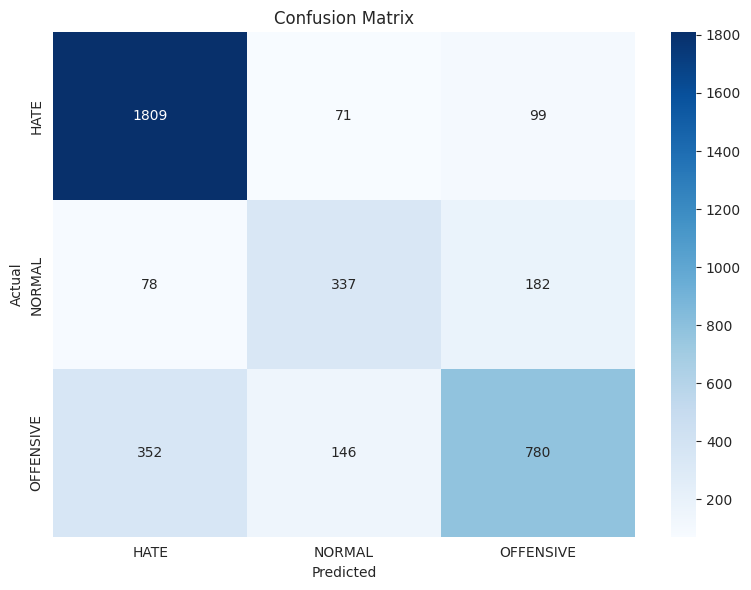


Macro-Averaged AUC: 0.9014
95% CI for Macro-Averaged AUC: [0.8937, 0.9092]
Saved ROC curve to: /content/drive/MyDrive/NLP_Projects/HateSpeech/4o_mini_on_human_majority/ALBERT_roc_curve.png


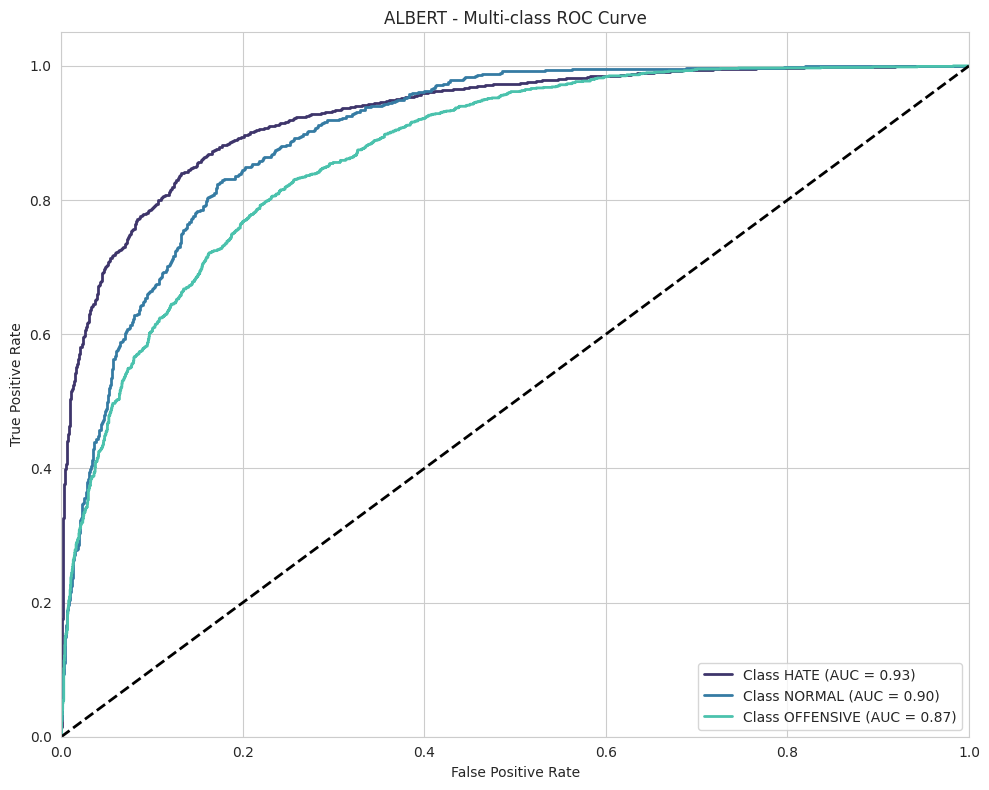

In [ ]:
best_albert.eval()
test_predictions_albert, test_labels_batch_albert, test_probabilities_albert = [], [], []

with torch.no_grad():
    for batch in test_loader_albert:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        outputs = best_albert(input_ids, attention_mask = attention_mask)
        preds = torch.argmax(outputs.logits, dim = 1)

        test_predictions_albert.extend(preds.cpu().numpy())
        test_labels_batch_albert.extend(labels.cpu().numpy())
        probs = torch.softmax(outputs.logits, dim = 1)[:, 1]
        test_probabilities_albert.extend(probs.cpu().numpy())

# Metrics
test_f1 = f1_score(test_labels_batch_albert, test_predictions_albert, average = "weighted")
test_accuracy = accuracy_score(test_labels_batch_albert, test_predictions_albert)

print(f"Test F-1 Score: {test_f1:.4f}, Test Accuracy: {test_accuracy:.4f}")

evaluate_pytorch_multiclass(
    model = best_albert,
    test_loader = test_loader_albert,
    device = device,
    label_encoder = label_encoder,
    model_name = "ALBERT"
)

#### Step 4: Model Interpretation

Validation samples for ALBERT: 3844
Baseline ALBERT weighted F1 on validation: 0.7423
Candidate words for permutation importance (first 20):
['the', 'to', 'and', 'user', 'you', 'of', 'is', 'not', 'in', 'that', 'are', 'it', 'white', 'for', 'they', 'number', 'this', 'all', 'have', 'be']
ALBERT mask token: [MASK]
Word 'the': masked F1=0.7387, ΔF1=0.0036
Word 'to': masked F1=0.7392, ΔF1=0.0031
Word 'and': masked F1=0.7420, ΔF1=0.0004
Word 'user': masked F1=0.7336, ΔF1=0.0088
Word 'you': masked F1=0.7395, ΔF1=0.0029
Word 'of': masked F1=0.7404, ΔF1=0.0020
Word 'is': masked F1=0.7396, ΔF1=0.0028
Word 'not': masked F1=0.7393, ΔF1=0.0030
Word 'in': masked F1=0.7425, ΔF1=-0.0002
Word 'that': masked F1=0.7400, ΔF1=0.0023
Word 'are': masked F1=0.7416, ΔF1=0.0008
Word 'it': masked F1=0.7414, ΔF1=0.0010
Word 'white': masked F1=0.7406, ΔF1=0.0017
Word 'for': masked F1=0.7432, ΔF1=-0.0009
Word 'they': masked F1=0.7424, ΔF1=-0.0000
Word 'number': masked F1=0.7393, ΔF1=0.0031
Word 'this': masked F1=0.7

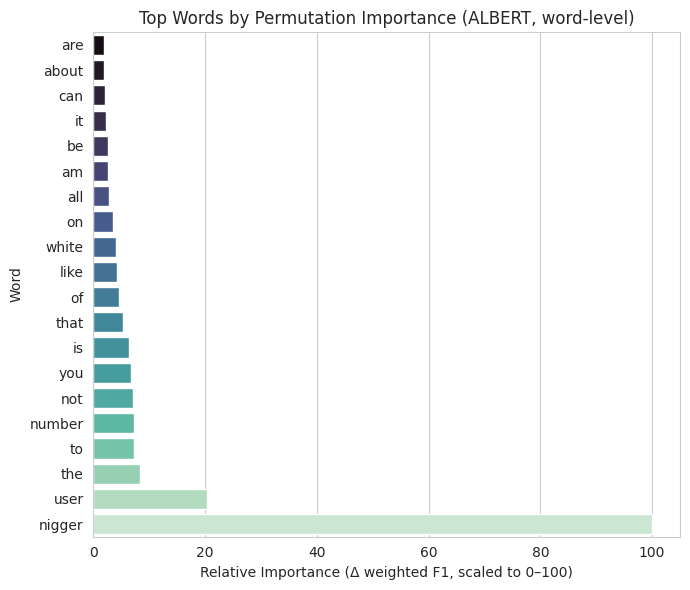

In [ ]:
# --------------------------------------------------
# 1. Use existing validation texts/labels for ALBERT
# --------------------------------------------------
# From your earlier code:
#   val_texts_albert = df_val_albert[TEXT_COLUMN].tolist()
#   val_labels_albert = df_val_albert[LABEL_COLUMN_ENCODED].tolist()

val_texts = list(val_texts_albert)
val_labels = np.array(val_labels_albert)

print(f"Validation samples for ALBERT: {len(val_texts)}")

# Max length consistent with training
MAX_LEN_ALBERT = MAX_TOKEN_LENGTH

# --------------------------------------------------
# 2. Helper: run ALBERT on a list of texts
# --------------------------------------------------

def albert_predict_from_texts(model, tokenizer, texts, device,
                              max_length = 128, batch_size = BATCH_SIZE):
    """
    Run a HuggingFace ALBERT classifier on a list of raw texts.
    Returns (pred_labels, prob_matrix).
    """
    model.eval()
    model.to(device)

    all_preds = []
    all_probs = []

    for start in range(0, len(texts), batch_size):
        batch_texts = texts[start:start + batch_size]
        enc = tokenizer(
            batch_texts,
            padding = True,
            truncation = True,
            max_length = max_length,
            return_tensors = "pt"
        )

        input_ids = enc["input_ids"].to(device)
        attention_mask = enc["attention_mask"].to(device)

        with torch.no_grad():
            outputs = model(input_ids = input_ids, attention_mask = attention_mask)
            logits = outputs.logits
            probs = torch.softmax(logits, dim = 1)
            preds = torch.argmax(probs, dim = 1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    return np.array(all_preds), np.array(all_probs)


# --------------------------------------------------
# 3. Baseline F1 on unperturbed validation texts
# --------------------------------------------------

baseline_preds, _ = albert_predict_from_texts(
    model = best_albert,
    tokenizer = tokenizer,                # <- your existing tokenizer
    texts = val_texts,
    device = device,
    max_length = MAX_LEN_ALBERT,
    batch_size = 32
)

baseline_f1_albert = f1_score(val_labels, baseline_preds, average = "weighted")
print(f"Baseline ALBERT weighted F1 on validation: {baseline_f1_albert:.4f}")

# --------------------------------------------------
# 4. Choose candidate *words* to probe
# --------------------------------------------------

# Build word frequencies from the same cleaned text representation
word_counter = Counter()
for txt in val_texts:
    if isinstance(txt, str):
        word_counter.update(txt.split())

def keep_word(w):
    # ignore empty strings and 1-char tokens (you can tighten this rule)
    return len(w) > 1

filtered_items = [(w, c) for w, c in word_counter.items() if keep_word(w)]
filtered_counter = Counter(dict(filtered_items))

TOP_WORDS = 50   # how many words to probe for importance
candidate_words = [w for (w, _) in filtered_counter.most_common(TOP_WORDS)]

print("Candidate words for permutation importance (first 20):")
print(candidate_words[:20])

mask_token = tokenizer.mask_token  # usually "[MASK]"
print("ALBERT mask token:", mask_token)

# --------------------------------------------------
# 5. Word-level permutation importance
# --------------------------------------------------

def mask_word_in_text(text, word, replacement):
    """Replace exact whitespace-delimited word with replacement."""
    if not isinstance(text, str):
        return text
    toks = text.split()
    toks = [replacement if t == word else t for t in toks]
    return " ".join(toks)

word_importances = []

for w in candidate_words:
    # skip if this word somehow never appears (defensive)
    if w not in filtered_counter:
        continue

    # produce perturbed texts with this word masked
    masked_texts = [mask_word_in_text(t, w, mask_token) for t in val_texts]

    masked_preds, _ = albert_predict_from_texts(
        model = best_albert,
        tokenizer = tokenizer,
        texts = masked_texts,
        device = device,
        max_length = MAX_LEN_ALBERT,
        batch_size = BATCH_SIZE
    )

    masked_f1 = f1_score(val_labels, masked_preds, average = "weighted")
    f1_drop = baseline_f1_albert - masked_f1

    word_importances.append({
        "Word": w,
        "Baseline_F1": baseline_f1_albert,
        "Masked_F1": masked_f1,
        "F1_Drop": f1_drop
    })

    print(f"Word '{w}': masked F1={masked_f1:.4f}, ΔF1={f1_drop:.4f}")

word_importances_df = pd.DataFrame(word_importances)
word_importances_df = word_importances_df.sort_values("F1_Drop", ascending = False)

print("\nTop 20 ALBERT word importances:")
print(word_importances_df.head(20))

# --------------------------------------------------
# 6. Scale and plot, saving to DRIVE_PROJECT_PATH
# --------------------------------------------------

max_drop = word_importances_df["F1_Drop"].max() or 1.0
word_importances_df["Scaled_Importance"] = (
    word_importances_df["F1_Drop"] / max_drop
) * 100.0

TOP_K_PLOT = 20
top_words_df = word_importances_df.head(TOP_K_PLOT).copy()
top_words_df = top_words_df.sort_values("Scaled_Importance", ascending = True)

plt.figure(figsize = (7, 6))
sns.set_style("whitegrid")
sns.barplot(
    x = "Scaled_Importance",
    y = "Word",
    data = top_words_df,
    orient = "h",
    palette = "mako"
)
plt.xlabel("Relative Importance (Δ weighted F1, scaled to 0–100)")
plt.ylabel("Word")
plt.title("Top Words by Permutation Importance (ALBERT, word-level)")
plt.tight_layout()

albert_imp_fig_path = os.path.join(DRIVE_PROJECT_PATH, "albert_token_importance_top20.png")
plt.savefig(albert_imp_fig_path, dpi = 300)
plt.show()

### 4.4 Save Predictions for DL models

In [ ]:
df_test_gru = df_gru[df_gru["split"] == "test"].copy()

# Sanity checks
assert len(df_test_gru) == len(test_labels_gru) == len(test_predictions_gru) == len(test_predictions_cnn) == len(test_predictions_albert)

y_true_gru = np.array(test_labels_gru)
gru_preds = np.array(test_predictions_gru)
gru_probs = np.array(test_probabilities_gru)

y_true_cnn = np.array(test_labels_true_cnn)
cnn_preds = np.array(test_predictions_cnn)
cnn_probs = np.array(test_probabilities_cnn)

y_true_albert = np.array(test_labels_batch_albert)
albert_preds = np.array(test_predictions_albert)
albert_prob_class1 = np.array(test_probabilities_albert)

# All true labels must match
assert np.array_equal(y_true_gru, y_true_cnn)
assert np.array_equal(y_true_gru, y_true_albert)
y_true = y_true_gru

true_label_names = label_encoder.inverse_transform(y_true)
gru_label_names = label_encoder.inverse_transform(gru_preds)
cnn_label_names = label_encoder.inverse_transform(cnn_preds)
albert_label_names = label_encoder.inverse_transform(albert_preds)

# ---------- KEY PART: construct id for DL in the same way ----------
if "id" in df_test_gru.columns:
    df_pred_dl = df_test_gru[["id", TEXT_COLUMN, LABEL_COLUMN_ENCODED]].copy()
else:
    df_pred_dl = df_test_gru[[TEXT_COLUMN, LABEL_COLUMN_ENCODED]].copy()
    df_pred_dl.insert(0, "id", df_test_gru.index)

df_pred_dl = df_pred_dl.rename(columns={
    TEXT_COLUMN: "text",
    LABEL_COLUMN_ENCODED: "true_label_id"
})

df_pred_dl["true_label"] = true_label_names

df_pred_dl["gru_pred_id"] = gru_preds
df_pred_dl["gru_pred"] = gru_label_names

df_pred_dl["cnn_pred_id"] = cnn_preds
df_pred_dl["cnn_pred"] = cnn_label_names

df_pred_dl["albert_pred_id"] = albert_preds
df_pred_dl["albert_pred"] = albert_label_names

# GRU probs
num_classes = gru_probs.shape[1]
assert num_classes == len(label_encoder.classes_)

for i, class_name in enumerate(label_encoder.classes_):
    df_pred_dl[f"gru_prob_{class_name}"] = gru_probs[:, i]

# CNN probs
num_classes_cnn = cnn_probs.shape[1]
assert num_classes_cnn == len(label_encoder.classes_)

for i, class_name in enumerate(label_encoder.classes_):
    df_pred_dl[f"cnn_prob_{class_name}"] = cnn_probs[:, i]

# ALBERT (single class prob for now)
df_pred_dl["albert_prob_class1"] = albert_prob_class1

df_pred_dl["split"] = "test"

save_path = os.path.join(DRIVE_PROJECT_PATH, "dl_models_predictions.csv")
df_pred_dl.to_csv(save_path, index=False)
print(f"Saved DL predictions to: {save_path}")

Saved DL predictions to: /content/drive/MyDrive/NLP_Projects/HateSpeech/4o_mini_on_human_majority/dl_models_predictions.csv


# 5. Model Comparison

In [ ]:
# ====================================================
# 1. Read ML & DL prediction files
# ====================================================

ml_path = os.path.join(DRIVE_PROJECT_PATH, "ml_models_predictions.csv")
dl_path = os.path.join(DRIVE_PROJECT_PATH, "dl_models_predictions.csv")

df_ml = pd.read_csv(ml_path)
df_dl = pd.read_csv(dl_path)

print("ML columns:", df_ml.columns.tolist())
print("DL columns:", df_dl.columns.tolist())

# Sanity: both must have an 'id' and consistent truth columns
assert "id" in df_ml.columns and "id" in df_dl.columns, "Both files must have an 'id' column."
assert "true_label_id" in df_ml.columns and "true_label_id" in df_dl.columns, \
    "Both files must have 'true_label_id' column."
assert "true_label" in df_ml.columns and "true_label" in df_dl.columns, \
    "Both files must have 'true_label' column."

# ====================================================
# 2. Merge so rows are aligned across ML & DL
# ====================================================

df = pd.merge(
    df_ml,
    df_dl,
    on = ["id", "true_label", "true_label_id"],
    suffixes = ("_ml", "_dl")
)

print("Merged shape:", df.shape)
print("Merged columns:", df.columns.tolist())

# At this point we *already* enforce that true_label / true_label_id match
# across ML and DL via the merge keys, so no need for extra *_ml / *_dl checks.

# ====================================================
# 3. Build y_true and model predictions in *integer* space
# ====================================================

# Use the common true_label_id as ground truth
y_true = df["true_label_id"].values    # <--- UPDATED

# --- ML models: they are stored as strings, need to encode with label_encoder ---
lr_pred_str = df["lr_pred"].values
svm_pred_str = df["svm_pred"].values
rf_pred_str = df["rf_pred"].values
lgbm_pred_str = df["lgbm_pred"].values

# Map strings -> integer class ids using the same label_encoder
lr_pred = label_encoder.transform(lr_pred_str)
svm_pred = label_encoder.transform(svm_pred_str)
rf_pred = label_encoder.transform(rf_pred_str)
lgbm_pred = label_encoder.transform(lgbm_pred_str)

# --- DL models: already have *_pred_id in the DL file ---
gru_pred = df["gru_pred_id"].values
albert_pred = df["albert_pred_id"].values
cnn_pred = df["cnn_pred_id"].values

# Final sanity checks on lengths
n = len(y_true)
for name, arr in [
    ("LR", lr_pred),
    ("SVM", svm_pred),
    ("RF", rf_pred),
    ("LGBM", lgbm_pred),
    ("ALBERT", albert_pred),
    ("GRU", gru_pred),
    ("CNN", cnn_pred),
]:
    assert len(arr) == n, f"Length mismatch for {name}: got {len(arr)}, expected {n}"


# ====================================================
# 4. McNemar pairwise function
# ====================================================

def mcnemar_pairwise(y_true, model_preds, method="bonferroni"):
    y_true = np.asarray(y_true)
    model_names = list(model_preds.keys())
    results = []

    for m1, m2 in combinations(model_names, 2):
        y1 = np.asarray(model_preds[m1])
        y2 = np.asarray(model_preds[m2])

        assert len(y1) == len(y_true) == len(y2), f"Length mismatch for {m1} vs {m2}"

        m1_correct = (y1 == y_true)
        m2_correct = (y2 == y_true)

        a = np.sum(m1_correct & m2_correct)
        b = np.sum(m1_correct & ~m2_correct)
        c = np.sum(~m1_correct & m2_correct)
        d = np.sum(~m1_correct & ~m2_correct)

        table = np.array([[a, b],
                          [c, d]])

        res = mcnemar(table, exact = False, correction = True)
        p = res.pvalue

        if p >= 0.05:
            winner = "Inconclusive"
        elif b > c:
            winner = f"{m1} > {m2}"
        elif c > b:
            winner = f"{m2} > {m1}"
        else:
            winner = "Tie discordant"

        results.append({
            "Model 1": m1,
            "Model 2": m2,
            "a_both_correct": a,
            "b_m1_only_correct": b,
            "c_m2_only_correct": c,
            "d_both_wrong": d,
            "Statistic": res.statistic,
            "Raw p-value": p,
            "Winner (uncorrected)": winner
        })

    raw_pvals = [r["Raw p-value"] for r in results]
    _, corrected_pvals, _, _ = multipletests(raw_pvals, method=method)

    for i, p_corr in enumerate(corrected_pvals):
        results[i]["Corrected p-value"] = p_corr
        results[i]["Significant"] = "Yes" if p_corr < 0.05 else "No"

    df_res = pd.DataFrame(results)
    print(f"\nPairwise McNemar Tests (corrected with '{method}'):\n")
    print(df_res[[
        "Model 1", "Model 2",
        "a_both_correct", "b_m1_only_correct", "c_m2_only_correct", "d_both_wrong",
        "Statistic", "Raw p-value", "Corrected p-value", "Significant",
        "Winner (uncorrected)"
    ]])

    return df_res


# ====================================================
# 5. Build model_preds dict and run comparison
# ====================================================

model_preds = {
    "LR": lr_pred,
    "SVM": svm_pred,
    "RandomForest": rf_pred,
    "LGBM": lgbm_pred,
    "ALBERT": albert_pred,
    "GRU": gru_pred,
    "CNN": cnn_pred,
}

df_mcnemar = mcnemar_pairwise(
    y_true = y_true,
    model_preds = model_preds,
    method = "bonferroni"
)

ML columns: ['id', 'text_orig', 'text_ml', 'true_label', 'true_label_id', 'lr_pred', 'svm_pred', 'rf_pred', 'lgbm_pred', 'lr_prob_HATE', 'svm_prob_HATE', 'rf_prob_HATE', 'lgbm_prob_HATE', 'lr_prob_NORMAL', 'svm_prob_NORMAL', 'rf_prob_NORMAL', 'lgbm_prob_NORMAL', 'lr_prob_OFFENSIVE', 'svm_prob_OFFENSIVE', 'rf_prob_OFFENSIVE', 'lgbm_prob_OFFENSIVE', 'split']
DL columns: ['id', 'text', 'true_label_id', 'true_label', 'gru_pred_id', 'gru_pred', 'cnn_pred_id', 'cnn_pred', 'albert_pred_id', 'albert_pred', 'gru_prob_HATE', 'gru_prob_NORMAL', 'gru_prob_OFFENSIVE', 'cnn_prob_HATE', 'cnn_prob_NORMAL', 'cnn_prob_OFFENSIVE', 'albert_prob_class1', 'split']
Merged shape: (3854, 37)
Merged columns: ['id', 'text_orig', 'text_ml', 'true_label', 'true_label_id', 'lr_pred', 'svm_pred', 'rf_pred', 'lgbm_pred', 'lr_prob_HATE', 'svm_prob_HATE', 'rf_prob_HATE', 'lgbm_prob_HATE', 'lr_prob_NORMAL', 'svm_prob_NORMAL', 'rf_prob_NORMAL', 'lgbm_prob_NORMAL', 'lr_prob_OFFENSIVE', 'svm_prob_OFFENSIVE', 'rf_prob_OFFEN